In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

pd.set_option('display.max_columns', None)

%load_ext rpy2.ipython

In [2]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
%%R

set.seed(42)

# Set up gene lists

In [4]:
%%R
msigdbr_species()

# A tibble: 20 × 2
   species_name                    species_common_name                          
   <chr>                           <chr>                                        
 1 Anolis carolinensis             Carolina anole, green anole                  
 2 Bos taurus                      bovine, cattle, cow, dairy cow, domestic cat…
 3 Caenorhabditis elegans          <NA>                                         
 4 Canis lupus familiaris          dog, dogs                                    
 5 Danio rerio                     leopard danio, zebra danio, zebra fish, zebr…
 6 Drosophila melanogaster         fruit fly                                    
 7 Equus caballus                  domestic horse, equine, horse                
 8 Felis catus                     cat, cats, domestic cat                      
 9 Gallus gallus                   bantam, chicken, chickens, Gallus domesticus 
10 Homo sapiens                    human                                        
11 Macaca

In [5]:
%%R

all_gene_sets = msigdbr(species = "human")
head(all_gene_sets)

# A tibble: 6 × 15
  gs_cat gs_subcat      gs_name        gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>          <chr>          <chr>             <int> <chr>          
1 C3     MIR:MIR_Legacy AAACCAC_MIR140 ABCC4             10257 ENSG00000125257
2 C3     MIR:MIR_Legacy AAACCAC_MIR140 ABRAXAS2          23172 ENSG00000165660
3 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACTN4                81 ENSG00000130402
4 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACTN4                81 ENSG00000282844
5 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACVR1                90 ENSG00000115170
6 C3     MIR:MIR_Legacy AAACCAC_MIR140 ADAM9              8754 ENSG00000168615
# ℹ 9 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>


In [6]:
%%R

# Get the MSigDB collections
collections <- msigdbr_collections()

# Print all rows of the tibble
print(collections, n = Inf)

# A tibble: 23 × 3
   gs_cat gs_subcat         num_genesets
   <chr>  <chr>                    <int>
 1 C1     ""                         299
 2 C2     "CGP"                     3384
 3 C2     "CP"                        29
 4 C2     "CP:BIOCARTA"              292
 5 C2     "CP:KEGG"                  186
 6 C2     "CP:PID"                   196
 7 C2     "CP:REACTOME"             1615
 8 C2     "CP:WIKIPATHWAYS"          664
 9 C3     "MIR:MIRDB"               2377
10 C3     "MIR:MIR_Legacy"           221
11 C3     "TFT:GTRD"                 518
12 C3     "TFT:TFT_Legacy"           610
13 C4     "CGN"                      427
14 C4     "CM"                       431
15 C5     "GO:BP"                   7658
16 C5     "GO:CC"                   1006
17 C5     "GO:MF"                   1738
18 C5     "HPO"                     5071
19 C6     ""                         189
20 C7     "IMMUNESIGDB"             4872
21 C7     "VAX"                      347
22 C8     ""                         7

In [7]:
%%R

#Retrieve human H (hallmark gene sets) 
msigdbr_df <- msigdbr(species = "human", category = "H")


head(msigdbr_df)

# A tibble: 6 × 15
  gs_cat gs_subcat gs_name               gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>     <chr>                 <chr>             <int> <chr>          
1 H      ""        HALLMARK_ADIPOGENESIS ABCA1                19 ENSG00000165029
2 H      ""        HALLMARK_ADIPOGENESIS ABCB8             11194 ENSG00000197150
3 H      ""        HALLMARK_ADIPOGENESIS ACAA2             10449 ENSG00000167315
4 H      ""        HALLMARK_ADIPOGENESIS ACADL                33 ENSG00000115361
5 H      ""        HALLMARK_ADIPOGENESIS ACADM                34 ENSG00000117054
6 H      ""        HALLMARK_ADIPOGENESIS ACADS                35 ENSG00000122971
# ℹ 9 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>


In [8]:
%%R

pathwaysH = split(x = msigdbr_df$gene_symbol, f = msigdbr_df$gs_name)
head(pathwaysH)

$HALLMARK_ADIPOGENESIS
  [1] "ABCA1"    "ABCB8"    "ACAA2"    "ACADL"    "ACADM"    "ACADS"   
  [7] "ACLY"     "ACO2"     "ACOX1"    "ADCY6"    "ADIG"     "ADIPOQ"  
 [13] "ADIPOR2"  "ADIPOR2"  "AGPAT3"   "AIFM1"    "AK2"      "ALDH2"   
 [19] "ALDOA"    "ANGPT1"   "ANGPTL4"  "APLP2"    "APOE"     "ARAF"    
 [25] "ARL4A"    "ATL2"     "ATP1B3"   "ATP5PO"   "BAZ2A"    "BCKDHA"  
 [31] "BCL2L13"  "BCL6"     "C3"       "CAT"      "CAVIN1"   "CAVIN2"  
 [37] "CCNG2"    "CD151"    "CD302"    "CD36"     "CDKN2C"   "CHCHD10" 
 [43] "CHCHD10"  "CHCHD10"  "CHUK"     "CIDEA"    "CMBL"     "CMPK1"   
 [49] "COL15A1"  "COL4A1"   "COQ3"     "COQ5"     "COQ9"     "COX6A1"  
 [55] "COX7B"    "COX8A"    "CPT2"     "CRAT"     "CS"       "CYC1"    
 [61] "CYP4B1"   "DBT"      "DDT"      "DDT"      "DECR1"    "DGAT1"   
 [67] "DGAT1"    "DGAT1"    "DHCR7"    "DHRS7"    "DHRS7B"   "DLAT"    
 [73] "DLD"      "DNAJB9"   "DNAJC15"  "DRAM2"    "ECH1"     "ECH1"    
 [79] "ECHS1"    "ELMOD3"   "ELOVL6"   "E

In [9]:
%%R

options(ports=8888)

# NAWM_MOL

In [10]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_NAWMvWM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

        gene   logFC_WM         se       pvalue convergence pdHess     logLik
1     UBE2L6 -0.5477302 0.08091916 1.298045e-11           0   TRUE  -89.06084
2 AC092070.3 -0.8658267 0.13052000 3.274406e-11           0   TRUE  -71.48527
3    COL16A1  0.8434234 0.13003339 8.802440e-11           0   TRUE -208.32590
4   C11orf68 -0.4394771 0.06830524 1.242751e-10           0   TRUE -131.53930
5        TOX -2.0204192 0.31601561 1.622202e-10           0   TRUE -121.29810
6     GPR160 -0.6561005 0.10339589 2.216782e-10           0   TRUE  -87.08201
       AIC error          FDR status
1 196.1217    NA 1.295774e-07     OK
2 160.9705    NA 2.179117e-07     OK
3 434.6518    NA 4.393518e-07     OK
4 281.0786    NA 4.962305e-07     OK
5 260.5962    NA 5.397877e-07     OK
6 192.1640    NA 6.322579e-07     OK


In [11]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [12]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 218
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
717     VIM -4.135007 1.2871714 1.315961e-03           0   TRUE  -82.99926
31  FAM107A -3.980043 0.7592090 1.585396e-07           0   TRUE -103.77714
590   ULBP1 -3.534997 1.0517552 7.764798e-04           0   TRUE  -31.61647
963   TIMP1 -3.273039 1.0959899 2.823039e-03           0   TRUE  -73.46619
477   CEBPD -3.112009 0.8873316 4.529268e-04           0   TRUE -129.28982
48     GFAP -2.892880 0.5735575 4.564999e-07           0   TRUE -151.87273
          AIC error          FDR status logFC_rev
717 183.99852    NA 2.815986e-02     OK  4.135007
31  225.55427    NA 7.836528e-05     OK  3.980043
590  81.23295    NA 2.008658e-02     OK  3.534997
963 164.93239    NA 4.451388e-02     OK  3.273039
477 276.57963    NA 1.419574e-02     OK  3.112009
48  321.74547    NA 1.446670e-04     OK  2.892880


In [13]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 110
         gene logFC_WM        se       pvalue convergence pdHess     logLik
545    GLB1L3 2.036797 0.5963045 6.361828e-04           0   TRUE  -52.70157
80  LINC02389 1.818494 0.3900799 3.133806e-06           0   TRUE  -97.67698
380     PARVA 1.663563 0.4543404 2.507525e-04           0   TRUE  -75.97794
616    AHNAK2 1.625008 0.4872704 8.532366e-04           0   TRUE -114.78986
807       EGF 1.622252 0.5194641 1.790584e-03           0   TRUE  -56.30803
840      CDH4 1.586917 0.5127743 1.969676e-03           0   TRUE -203.88115
         AIC error          FDR status logFC_rev
545 123.4031    NA 0.0176899576     OK -2.036797
80  213.3540    NA 0.0005636616     OK -1.818494
380 169.9559    NA 0.0099615312     OK -1.663563
616 247.5797    NA 0.0212410760     OK -1.625008
807 130.6161    NA 0.0340466750     OK -1.622252
840 425.7623    NA 0.0358928220     OK -1.586917


In [226]:
%%R

dim(df)

[1] 15298    12


In [227]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "UBE2L6"     "AC092070.3" "COL16A1"    "C11orf68"   "TOX"       
[6] "GPR160"    


In [228]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [229]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 15298    12


In [230]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 15298"
[1] "Range of Z-scores: -6.49 to 6.77"
    UBE2L6 AC092070.3   C11orf68        TOX     GPR160    ST8SIA5       ECI1 
  6.768856   6.633670   6.434017   6.393416   6.345518   6.315384   6.142827 
     SCAF1      PELI3      CHSY3 
  6.112013   6.101499   6.059308 


In [231]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


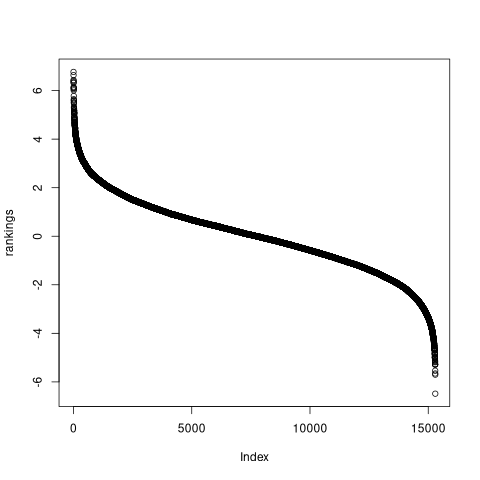

In [232]:
%%R

plot(rankings)

In [233]:
%%R

max(rankings)

[1] 6.768856


In [234]:
%%R

min(rankings)

[1] -6.486207


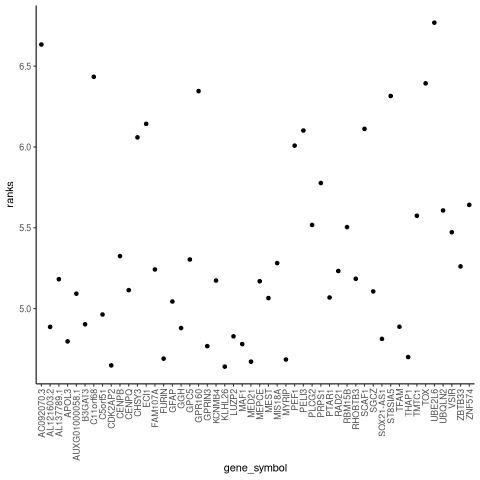

In [235]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [236]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [237]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 5.222865e-02 1.145851e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.346535e-01 2.537700e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 6.295733e-02 1.285379e-01
 4:                   HALLMARK_APICAL_JUNCTION 1.402806e-01 2.545832e-01
 5:                    HALLMARK_APICAL_SURFACE 9.216867e-01 9.521040e-01
 6:                         HALLMARK_APOPTOSIS 8.150522e-03 3.072120e-02
 7:              HALLMARK_BILE_ACID_METABOLISM 9.604167e-01 9.604167e-01
 8:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 3.944223e-01 5.085972e-01
 9:                       HALLMARK_COAGULATION 7.099386e-02 1.391480e-01
10:                        HALLMARK_COMPLEMENT 2.767793e-05 2.712437e-04
11:                        HALLMARK_DNA_REPAIR 1.553398e-02 4.760895e-02
12:                       HALLMARK_E2F_TARGETS 3.60

In [238]:
%%R

dim(fgsea_res)

[1] 49  8


In [239]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_ALvWM_GvC_all.csv")

In [240]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 20  8


In [241]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                         HALLMARK_APOPTOSIS 8.150522e-03 0.0307211977
2:                        HALLMARK_COMPLEMENT 2.767793e-05 0.0002712437
3:                        HALLMARK_DNA_REPAIR 1.553398e-02 0.0476089526
4:                       HALLMARK_E2F_TARGETS 3.606451e-04 0.0025245156
5: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 6.384084e-03 0.0260683428
6:            HALLMARK_ESTROGEN_RESPONSE_LATE 2.625460e-02 0.0714708619
     log2err        ES      NES  size                               leadingEdge
       <num>     <num>    <num> <int>                                    <list>
1: 0.3807304 0.3573883 1.571727    94 BIRC3,IRF1,CLU,LGALS3,GADD45A,BCL2L11,...
2: 0.5756103 0.4184442 1.890718   118   GNB2,KCNIP3,ERAP2,ADRA2B,GP1BA,IRF1,...
3: 0.3807304 0.3382547 1.504450   108 CLP1,ADRM1,SSRP1,POLR1D,ARL6IP1,NELFB,...
4: 0.4984931 0.3681767 1

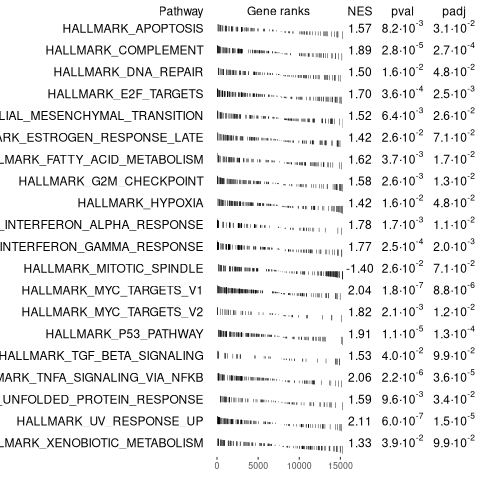

In [242]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

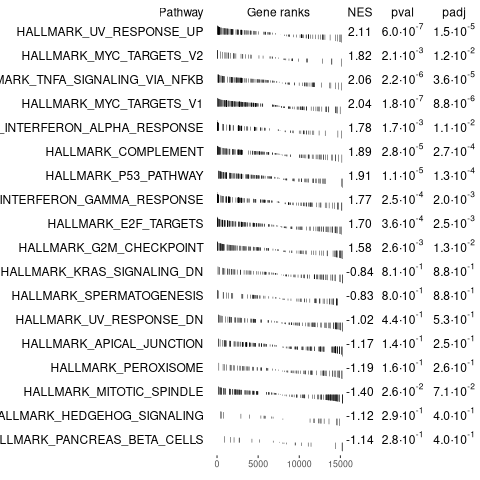

In [243]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [244]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

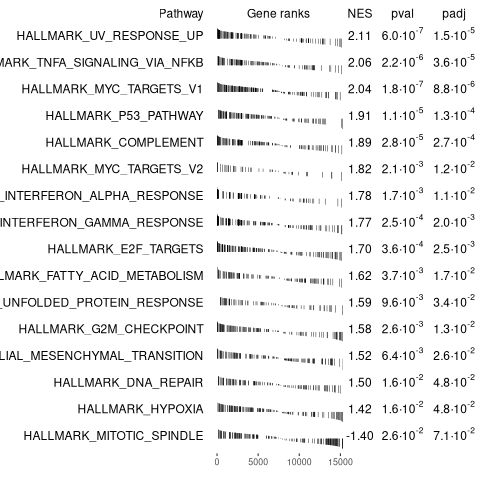

In [245]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [246]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

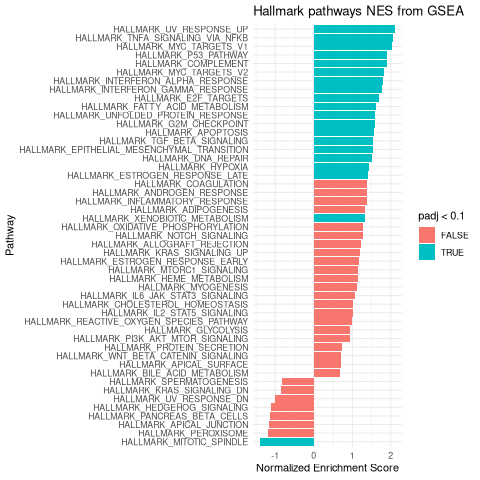

In [247]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [248]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                  padj   NES  size
  <chr>                                   <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            0.00000879  2.04   152
2 HALLMARK_UV_RESPONSE_UP            0.0000147   2.11   103
3 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.0000355   2.06   114
4 HALLMARK_P53_PATHWAY               0.000134    1.91   127
5 HALLMARK_COMPLEMENT                0.000271    1.89   118
6 HALLMARK_INTERFERON_GAMMA_RESPONSE 0.00205     1.77   116


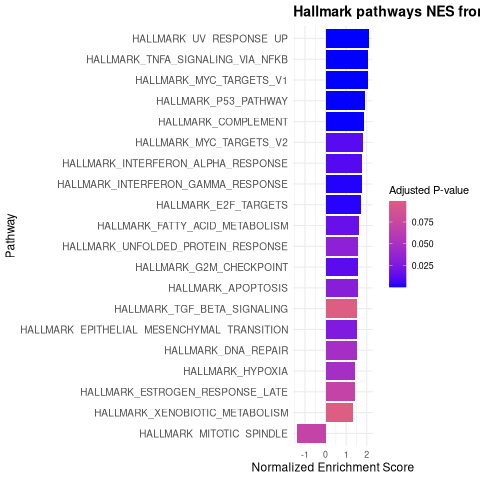

In [249]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

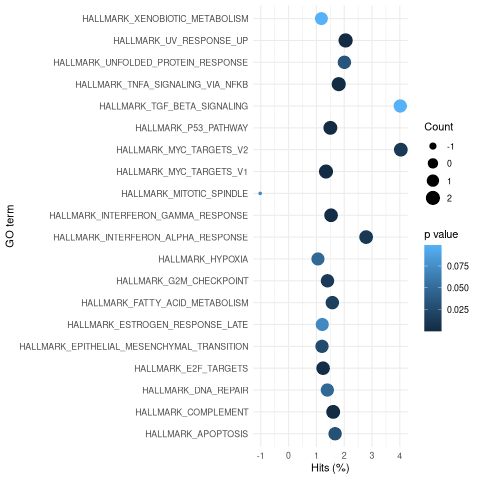

In [250]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [251]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                  padj   NES  size
  <chr>                                   <dbl> <dbl> <int>
1 HALLMARK_MYC_TARGETS_V1            0.00000879  2.04   152
2 HALLMARK_UV_RESPONSE_UP            0.0000147   2.11   103
3 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.0000355   2.06   114
4 HALLMARK_P53_PATHWAY               0.000134    1.91   127
5 HALLMARK_COMPLEMENT                0.000271    1.89   118
6 HALLMARK_INTERFERON_GAMMA_RESPONSE 0.00205     1.77   116


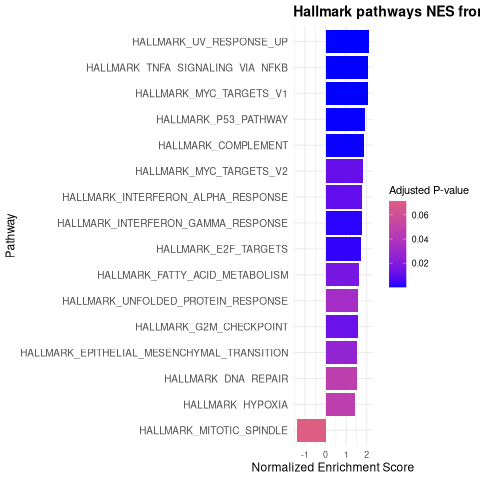

In [252]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [253]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                         padj   NES  size
  <chr>                          <dbl> <dbl> <int>
1 MYC_TARGETS_V1            0.00000879  2.04   152
2 UV_RESPONSE_UP            0.0000147   2.11   103
3 TNFA_SIGNALING_VIA_NFKB   0.0000355   2.06   114
4 P53_PATHWAY               0.000134    1.91   127
5 COMPLEMENT                0.000271    1.89   118
6 INTERFERON_GAMMA_RESPONSE 0.00205     1.77   116


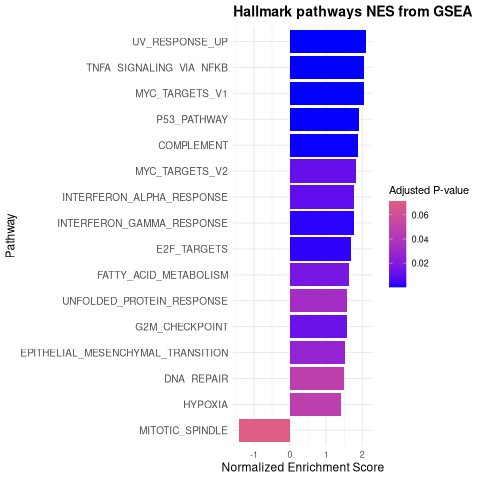

In [254]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

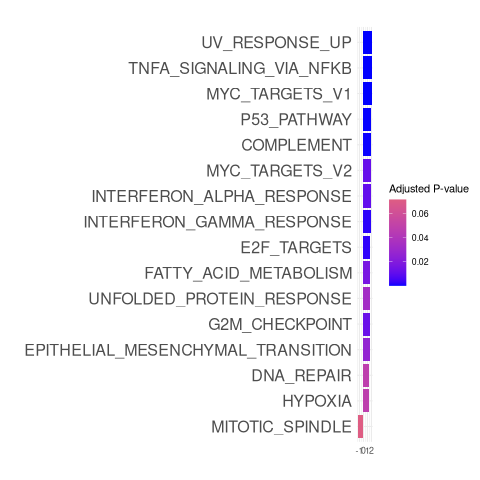

In [255]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_NAWM_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [256]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [257]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore.csv")

In [258]:
%%R
unique(fgsea_MOL2_significant$pathway)

 [1] "HALLMARK_APOPTOSIS"                        
 [2] "HALLMARK_COMPLEMENT"                       
 [3] "HALLMARK_DNA_REPAIR"                       
 [4] "HALLMARK_E2F_TARGETS"                      
 [5] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
 [6] "HALLMARK_ESTROGEN_RESPONSE_LATE"           
 [7] "HALLMARK_FATTY_ACID_METABOLISM"            
 [8] "HALLMARK_G2M_CHECKPOINT"                   
 [9] "HALLMARK_HYPOXIA"                          
[10] "HALLMARK_INTERFERON_ALPHA_RESPONSE"        
[11] "HALLMARK_INTERFERON_GAMMA_RESPONSE"        
[12] "HALLMARK_MITOTIC_SPINDLE"                  
[13] "HALLMARK_MYC_TARGETS_V1"                   
[14] "HALLMARK_MYC_TARGETS_V2"                   
[15] "HALLMARK_P53_PATHWAY"                      
[16] "HALLMARK_TGF_BETA_SIGNALING"               
[17] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"          
[18] "HALLMARK_UNFOLDED_PROTEIN_RESPONSE"        
[19] "HALLMARK_UV_RESPONSE_UP"                   
[20] "HALLMARK_XENOBIOTIC_METABOLISM"            


In [259]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "UBE2L6"   "HLA-B"    "PSMB8"    "TAPBP"    "NFKBIA"   "PSME1"   
 [7] "CIITA"    "IRF1"     "PIM1"     "PML"      "APOL6"    "IFIH1"   
[13] "CDKN1A"   "NMI"      "SAMHD1"   "PTPN6"    "CD40"     "CD38"    
[19] "TXNIP"    "HLA-A"    "CASP4"    "EIF2AK2"  "MTHFD2"   "B2M"     
[25] "IRF7"     "ADAR"     "SOCS3"    "PSMB2"    "TOR1B"    "STAT3"   
[31] "TRIM25"   "SERPING1" "HERC6"    "TRIM26"   "PSMB9"    "NOD1"    
[37] "RTP4"     "PARP12"   "TAP1"     "IFITM3"  


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# AL_MOL

In [174]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_ALvWM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

    gene   logFC_WM         se       pvalue convergence pdHess     logLik
1 FGFRL1  1.1738705 0.14055174 6.718800e-17           0   TRUE -111.18380
2 WRAP53 -0.6017076 0.07615584 2.766644e-15           0   TRUE -111.52958
3   SGCZ -3.2753774 0.42563905 1.412734e-14           0   TRUE -241.34958
4 GPRIN3 -3.9587244 0.52002134 2.685965e-14           0   TRUE  -89.73582
5 PTPDC1  0.6086374 0.08086415 5.205239e-14           0   TRUE -191.02072
6   PSD3  0.6931467 0.09745717 1.141073e-12           0   TRUE -254.17709
       AIC error          FDR status
1 240.3676    NA 1.210526e-12     OK
2 241.0592    NA 2.492331e-11     OK
3 500.6992    NA 8.484408e-11     OK
4 197.4716    NA 1.209826e-10     OK
5 400.0414    NA 1.875656e-10     OK
6 526.3542    NA 3.426453e-09     OK


In [175]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [176]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 443
       gene  logFC_WM       se       pvalue convergence pdHess    logLik
715  MAPK11 -5.772282 1.657699 4.974899e-04           0   TRUE -37.50570
441     VGF -5.640046 1.460401 1.124704e-04           0   TRUE -51.91877
369    LY6H -5.529655 1.383451 6.414998e-05           0   TRUE -48.02741
1065  EGFL7 -5.091464 1.604086 1.503228e-03           0   TRUE -36.70474
1465  ARL4C -4.737367 1.631160 3.680842e-03           0   TRUE -68.95552
326   PTPRN -4.608971 1.128224 4.404692e-05           0   TRUE -50.55652
           AIC error         FDR status logFC_rev
715   93.01139    NA 0.011045214     OK  5.772282
441  121.83753    NA 0.004044669     OK  5.640046
369  114.05483    NA 0.002785037     OK  5.529655
1065  91.40949    NA 0.022073079     OK  5.091464
1465 155.91103    NA 0.039218057     OK  4.737367
326  119.11305    NA 0.002185720     OK  4.608971


In [177]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 411
           gene logFC_WM        se       pvalue convergence pdHess     logLik
1002     AHNAK2 2.597480 0.8078429 1.302953e-03           0   TRUE  -97.19964
266  AC114485.1 2.467304 0.5819377 2.237107e-05           0   TRUE -168.90979
12    LINC00891 2.164087 0.3413514 2.301198e-10           0   TRUE -109.18874
1197      EPAS1 2.125811 0.6923901 2.138796e-03           0   TRUE  -70.71847
1619       POMC 2.078927 0.7397869 4.951523e-03           0   TRUE  -66.43594
84        RAB7B 2.075214 0.4138116 5.306732e-07           0   TRUE -137.09835
          AIC error          FDR status logFC_rev
1002 212.3993    NA 2.034337e-02     OK -2.597480
266  355.8196    NA 1.370951e-03     OK -2.467304
12   236.3775    NA 3.189284e-07     OK -2.164087
1197 159.4369    NA 2.792389e-02     OK -2.125811
1619 150.8719    NA 4.773219e-02     OK -2.078927
84   292.1967    NA 1.062349e-04     OK -2.075214


In [178]:
%%R

dim(df)

[1] 14958    12


In [179]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "FGFRL1" "WRAP53" "SGCZ"   "GPRIN3" "PTPDC1" "PSD3"  


In [180]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [181]:
%%R

df[df$pvalue == 0, ]

     gene logFC_WM se pvalue convergence pdHess logLik AIC error FDR status
NA   <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.1 <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
     logFC_rev
NA          NA
NA.1        NA


In [182]:
%%R
df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 14956    12


In [183]:
%%R

# Filter the dataset for significant genes
filtered_df <- df[abs(df$logFC_rev) >= 0.585 & df$FDR < 0.05, ]

# Compute ranking score: sign(logFC) * -log10(P.Value)
filtered_df$ranking_score <- sign(filtered_df$logFC_rev) * -log10(filtered_df$FDR)

# Assign names to the rankings
rankings <- filtered_df$ranking_score
names(rankings) <- filtered_df$gene

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

In [184]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] FALSE


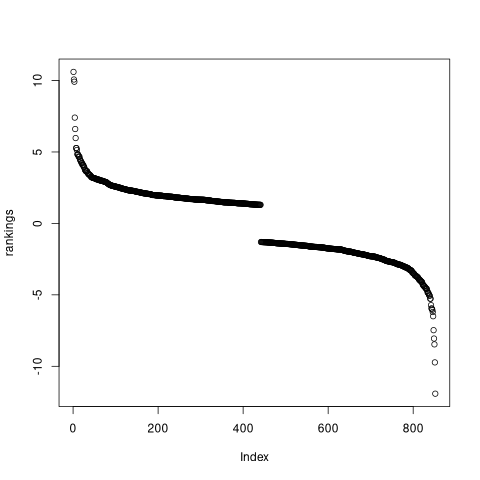

In [185]:
%%R

plot(rankings)

In [192]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 14956"
[1] "Range of Z-scores: -8.35 to 7.9"
   WRAP53      SGCZ    GPRIN3   FAM107A     FOXO4     LUZP2   RHOBTB3 LINC00278 
 7.901005  7.695200  7.612619  6.693120  6.390581  6.091200  5.768423  5.753760 
     CR1L     FURIN 
 5.692465  5.583514 


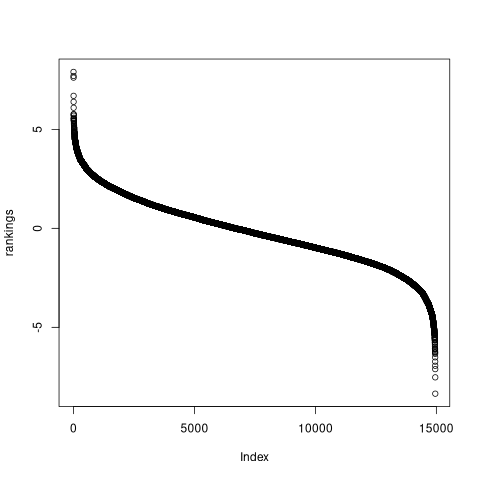

In [193]:
%%R

plot(rankings)

In [194]:
%%R

max(rankings)

[1] 7.901005


In [195]:
%%R

min(rankings)

[1] -8.351875


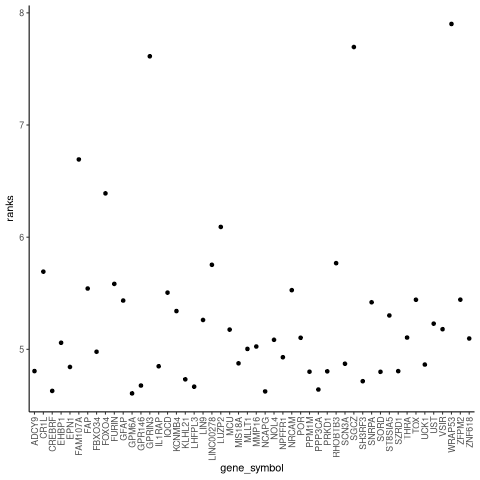

In [196]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [197]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [198]:
%%R
fgsea_res

                                       pathway         pval        padj
                                        <char>        <num>       <num>
 1:                      HALLMARK_ADIPOGENESIS 5.398773e-01 0.674846626
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.612903e-01 0.384024578
 3:                 HALLMARK_ANDROGEN_RESPONSE 6.454082e-01 0.717120181
 4:                      HALLMARK_ANGIOGENESIS 2.374582e-01 0.490861619
 5:                   HALLMARK_APICAL_JUNCTION 3.501577e-01 0.530542013
 6:                    HALLMARK_APICAL_SURFACE 9.397590e-02 0.293674699
 7:                         HALLMARK_APOPTOSIS 9.016393e-01 0.920040147
 8:              HALLMARK_BILE_ACID_METABOLISM 4.910859e-01 0.646165657
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 6.388889e-01 0.717120181
10:                       HALLMARK_COAGULATION 3.897764e-01 0.559006211
11:                        HALLMARK_COMPLEMENT 1.507583e-03 0.012563194
12:                        HALLMARK_DNA_REPAIR 9.622642e-01 0.96

In [199]:
%%R

dim(fgsea_res)

[1] 50  8


In [200]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_ALvWM_GvC_all.csv")

In [201]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 9 8


In [202]:
%%R

head(fgsea_MOL2_significant)

                              pathway         pval        padj   log2err
                               <char>        <num>       <num>     <num>
1:                HALLMARK_COMPLEMENT 0.0015075833 0.012563194 0.4550599
2:               HALLMARK_E2F_TARGETS 0.0066621619 0.041638512 0.4070179
3:     HALLMARK_INFLAMMATORY_RESPONSE 0.0136699396 0.075944109 0.3807304
4: HALLMARK_INTERFERON_ALPHA_RESPONSE 0.0000323653 0.001079487 0.5573322
5: HALLMARK_INTERFERON_GAMMA_RESPONSE 0.0000604898 0.001079487 0.5573322
6: HALLMARK_OXIDATIVE_PHOSPHORYLATION 0.0036469889 0.026049921 0.4317077
           ES       NES  size                              leadingEdge
        <num>     <num> <int>                                   <list>
1:  0.3205286  1.574431   124     ZFPM2,CR1,ZEB1,ADRA2B,FDX1,CEBPB,...
2:  0.2929721  1.456733   140    STAG1,RAD51C,POLE,PPM1D,RAD21,TK1,...
3:  0.3141816  1.482277    99  TAPBP,FZD5,PCDH7,NOD2,GNA15,EIF2AK2,...
4:  0.4518572  2.004827    73 ADAR,GBP2,IFIH1,EIF2AK2,HELZ2,T

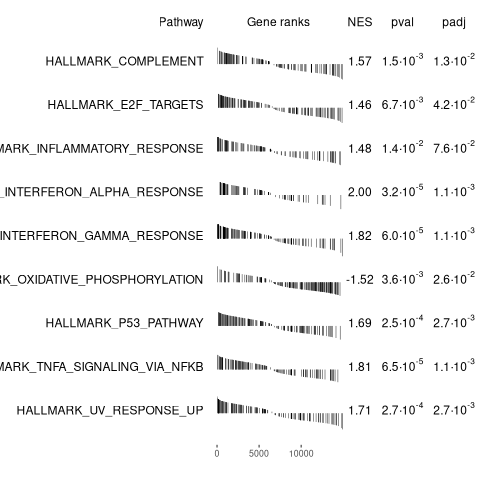

In [203]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

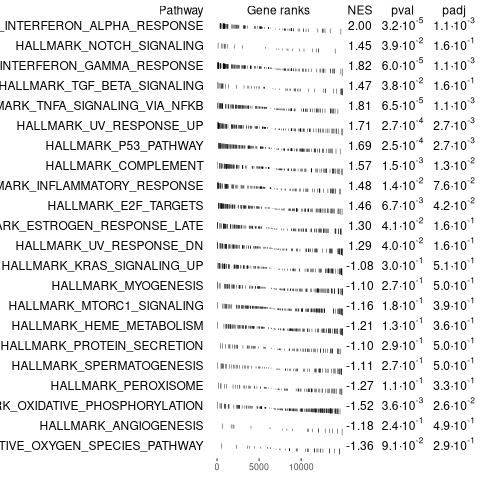

In [204]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [205]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

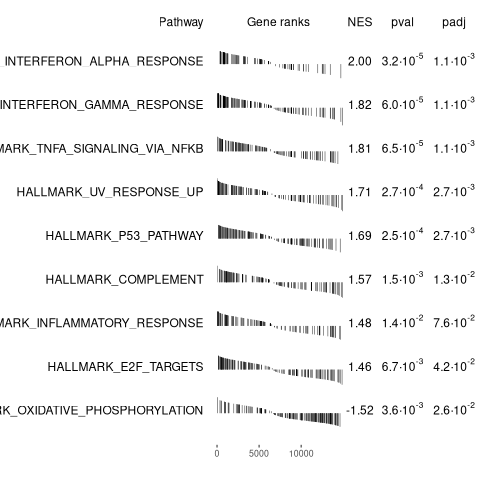

In [206]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [207]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

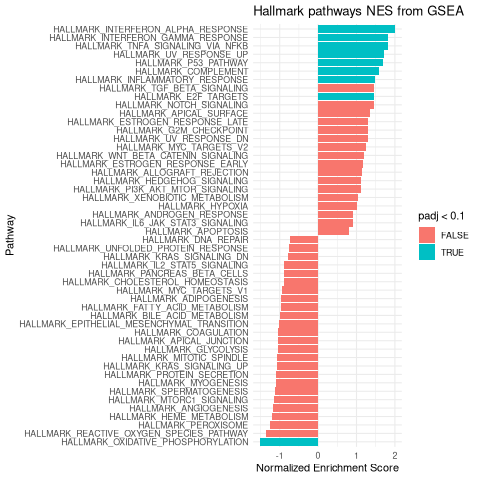

In [208]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [209]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.00108  2.00    73
2 HALLMARK_INTERFERON_GAMMA_RESPONSE 0.00108  1.82   117
3 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.00108  1.81   130
4 HALLMARK_UV_RESPONSE_UP            0.00269  1.71   120
5 HALLMARK_P53_PATHWAY               0.00269  1.69   144
6 HALLMARK_COMPLEMENT                0.0126   1.57   124


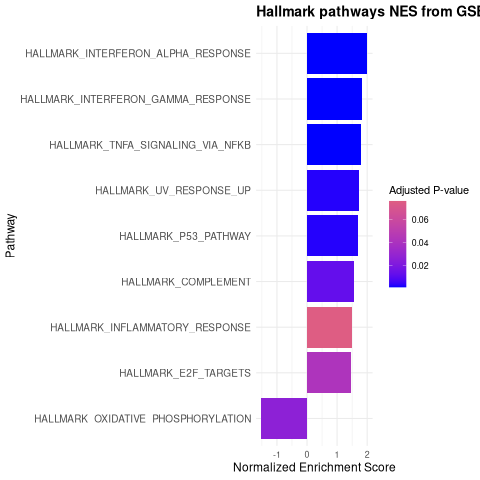

In [210]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

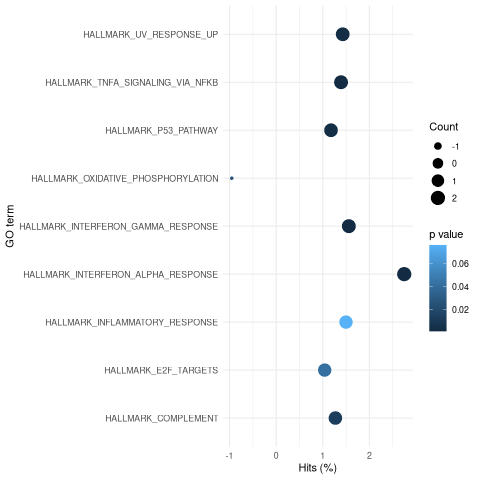

In [211]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [212]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.00108  2.00    73
2 HALLMARK_INTERFERON_GAMMA_RESPONSE 0.00108  1.82   117
3 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.00108  1.81   130
4 HALLMARK_UV_RESPONSE_UP            0.00269  1.71   120
5 HALLMARK_P53_PATHWAY               0.00269  1.69   144
6 HALLMARK_COMPLEMENT                0.0126   1.57   124


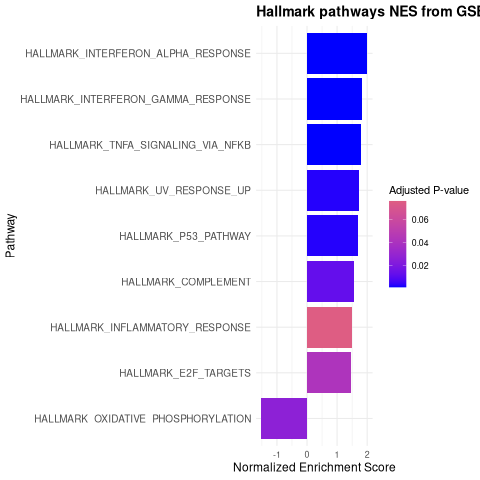

In [213]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [214]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                      padj   NES  size
  <chr>                       <dbl> <dbl> <int>
1 INTERFERON_ALPHA_RESPONSE 0.00108  2.00    73
2 INTERFERON_GAMMA_RESPONSE 0.00108  1.82   117
3 TNFA_SIGNALING_VIA_NFKB   0.00108  1.81   130
4 UV_RESPONSE_UP            0.00269  1.71   120
5 P53_PATHWAY               0.00269  1.69   144
6 COMPLEMENT                0.0126   1.57   124


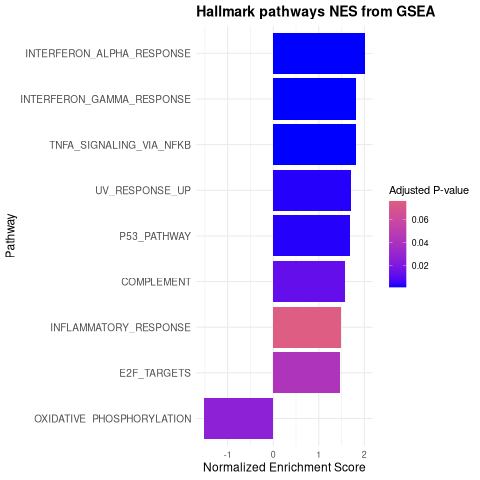

In [215]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

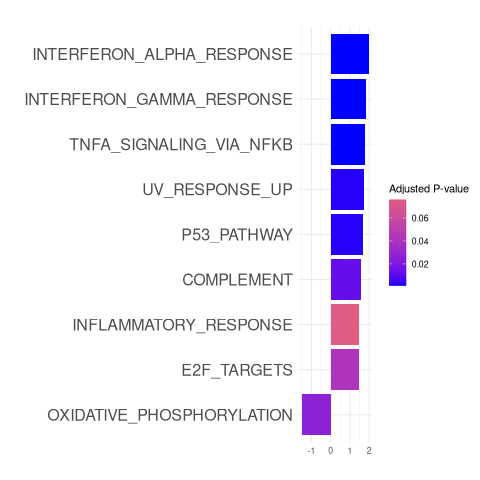

In [216]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [217]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [221]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_AL_all_glmm_zscore.csv")

In [219]:
%%R
unique(fgsea_MOL2_significant$pathway)

[1] "HALLMARK_COMPLEMENT"                "HALLMARK_E2F_TARGETS"              
[3] "HALLMARK_INFLAMMATORY_RESPONSE"     "HALLMARK_INTERFERON_ALPHA_RESPONSE"
[5] "HALLMARK_INTERFERON_GAMMA_RESPONSE" "HALLMARK_OXIDATIVE_PHOSPHORYLATION"
[7] "HALLMARK_P53_PATHWAY"               "HALLMARK_TNFA_SIGNALING_VIA_NFKB"  
[9] "HALLMARK_UV_RESPONSE_UP"           


In [220]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "TAPBP"    "HLA-B"    "TOR1B"    "NLRC5"    "ADAR"     "IFIH1"   
 [7] "EIF2AK2"  "HELZ2"    "CIITA"    "NFKBIA"   "TRIM26"   "UBE2L6"  
[13] "ISG20"    "PSMB8"    "PML"      "PTPN6"    "APOL6"    "CDKN1A"  
[19] "PARP12"   "IRF7"     "PARP14"   "HERC6"    "CASP7"    "IRF1"    
[25] "PIM1"     "SAMHD1"   "SLC25A28" "PLSCR1"   "EPSTI1"   "LATS2"   
[31] "NMI"      "TRIM25"   "IFI35"    "OGFR"     "CASP8"    "TXNIP"   
[37] "CD274"    "CD38"     "NFKB1"    "BTG1"     "MX1"      "SP110"   
[43] "PELI1"    "PSME1"    "CD74"     "STAT3"    "CMPK2"   


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CAL

In [260]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_CALvWM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

     gene   logFC_WM         se       pvalue convergence pdHess     logLik
1 CNTNAP3 -1.4027527 0.16544608 2.279016e-17           0   TRUE -166.84945
2 RHOBTB3 -0.9326450 0.11898531 4.566136e-15           0   TRUE -208.20926
3    CR1L -1.1347214 0.14795809 1.730610e-14           0   TRUE -122.55728
4 ST3GAL5  0.8234265 0.11967813 5.970894e-12           0   TRUE -198.80402
5  ZNF620  0.5214350 0.07630161 8.265626e-12           0   TRUE -110.86742
6  GPRIN3 -4.1321484 0.61295189 1.568774e-11           0   TRUE  -84.59865
       AIC error          FDR status
1 351.6989    NA 4.173107e-13     OK
2 434.4185    NA 4.180526e-11     OK
3 263.1146    NA 1.056307e-10     OK
4 415.6080    NA 2.186661e-08     OK
5 239.7348    NA 2.522531e-08     OK
6 187.1973    NA 4.103688e-08     OK


In [261]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [262]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 688
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
86    CLDN1 -4.445668 0.8867383 5.344691e-07           0   TRUE  -28.58624
1043  SPRY4 -4.245722 1.2631315 7.758578e-04           0   TRUE  -40.69941
6    GPRIN3 -4.132148 0.6129519 1.568774e-11           0   TRUE  -84.59865
26   RAB39A -3.840849 0.6711352 1.047119e-08           0   TRUE -122.52439
1315  NXPH3 -3.823672 1.1927362 1.346884e-03           0   TRUE  -38.95181
1232   BAG3 -3.759907 1.1584060 1.171380e-03           0   TRUE -176.22764
           AIC error          FDR status logFC_rev
86    75.17249    NA 1.063768e-04     OK  4.445668
1043  99.39881    NA 1.238599e-02     OK  4.245722
6    187.19730    NA 4.103688e-08     OK  4.132148
26   263.04878    NA 7.101408e-06     OK  3.840849
1315  95.90362    NA 1.710319e-02     OK  3.823672
1232 370.45527    NA 1.590003e-02     OK  3.759907


In [263]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 947
           gene logFC_WM        se       pvalue convergence pdHess     logLik
138        THY1 5.926476 1.2524961 2.226124e-06           0   TRUE  -74.54878
323  PPFIA2-AS1 3.857256 0.9237685 2.972470e-05           0   TRUE -128.47792
1291 AC025031.1 3.712907 1.1543994 1.298501e-03           0   TRUE  -59.44961
280      AHNAK2 3.700136 0.8696237 2.091703e-05           0   TRUE  -91.66481
384  AC104423.1 3.649544 0.8976287 4.787600e-05           0   TRUE  -79.03014
1023  LINC02278 3.611484 1.0698469 7.362768e-04           0   TRUE  -60.43459
          AIC error          FDR status logFC_rev
138  167.0976    NA 0.0002717504     OK -5.926476
323  274.9558    NA 0.0015730894     OK -3.857256
1291 136.8992    NA 0.0167797081     OK -3.712907
280  201.3296    NA 0.0012724640     OK -3.700136
384  176.0603    NA 0.0020872795     OK -3.649544
1023 138.8692    NA 0.0119726776     OK -3.611484


In [264]:
%%R

dim(df)

[1] 16952    12


In [265]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "CNTNAP3" "RHOBTB3" "CR1L"    "ST3GAL5" "ZNF620"  "GPRIN3" 


In [266]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [267]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 16942    12


In [268]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 16942"
[1] "Range of Z-scores: -6.88 to 8.48"
 CNTNAP3  RHOBTB3     CR1L   GPRIN3      FAP CNTNAP3C  TPD52L1   B3GAT3 
8.478609 7.838320 7.669208 6.741391 6.410317 5.984689 5.864545 5.840918 
  GPR146   SHISA6 
5.834378 5.816963 


In [269]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


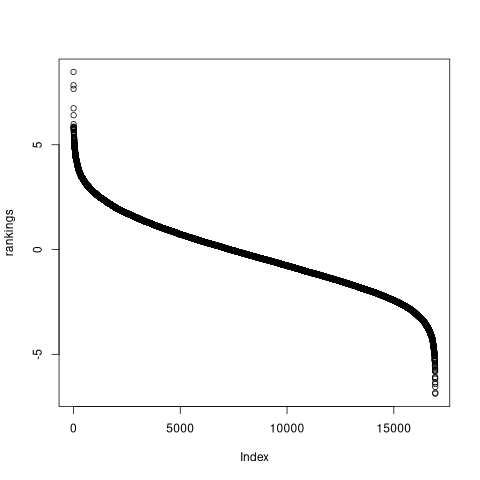

In [270]:
%%R

plot(rankings)

In [271]:
%%R

max(rankings)

[1] 8.478609


In [272]:
%%R

min(rankings)

[1] -6.880342


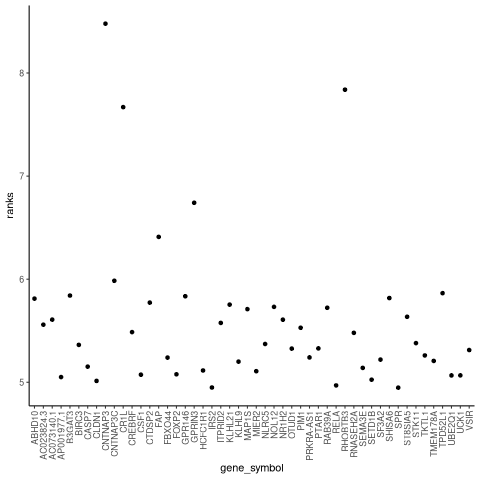

In [273]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [274]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [275]:
%%R
fgsea_res

                                       pathway         pval        padj
                                        <char>        <num>       <num>
 1:                      HALLMARK_ADIPOGENESIS 3.066298e-01 0.648011782
 2:               HALLMARK_ALLOGRAFT_REJECTION 9.779180e-02 0.376122300
 3:                 HALLMARK_ANDROGEN_RESPONSE 9.714286e-01 0.991253644
 4:                      HALLMARK_ANGIOGENESIS 7.869919e-01 0.948209472
 5:                   HALLMARK_APICAL_JUNCTION 6.550765e-01 0.877192982
 6:                    HALLMARK_APICAL_SURFACE 1.432665e-01 0.421371987
 7:                         HALLMARK_APOPTOSIS 6.434911e-01 0.877192982
 8:              HALLMARK_BILE_ACID_METABOLISM 8.629738e-01 0.980652001
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 8.956522e-01 0.991253644
10:                       HALLMARK_COAGULATION 2.884903e-01 0.648011782
11:                        HALLMARK_COMPLEMENT 2.493730e-02 0.155858136
12:                        HALLMARK_DNA_REPAIR 2.281690e-01 0.57

In [276]:
%%R

dim(fgsea_res)

[1] 50  8


In [277]:
%%R
library(data.table)

fwrite(fgsea_res, file = "./files/fgsea_CALvWM_all_OL_glmm_full.csv")

In [278]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 6 8


In [279]:
%%R

head(fgsea_MOL2_significant)

                              pathway         pval        padj   log2err
                               <char>        <num>       <num>     <num>
1:   HALLMARK_IL6_JAK_STAT3_SIGNALING 7.118055e-03 0.084741745 0.4070179
2: HALLMARK_INTERFERON_ALPHA_RESPONSE 6.300402e-03 0.084741745 0.4070179
3: HALLMARK_OXIDATIVE_PHOSPHORYLATION 3.558849e-04 0.008897122 0.4984931
4:               HALLMARK_P53_PATHWAY 8.652129e-05 0.004326065 0.5384341
5:   HALLMARK_TNFA_SIGNALING_VIA_NFKB 8.474175e-03 0.084741745 0.3807304
6:            HALLMARK_UV_RESPONSE_UP 1.082277e-02 0.090189763 0.3807304
           ES       NES  size                                leadingEdge
        <num>     <num> <int>                                     <list>
1:  0.3709850  1.591377    52   PIM1,CSF1,TYK2,IL17RB,TNFRSF1A,IL6ST,...
2:  0.3514354  1.615252    70     CSF1,IFIH1,EIF2AK2,IRF7,PARP9,GBP2,...
3: -0.3432584 -1.654517   182 HADHB,AFG3L2,COX11,NDUFV1,SURF1,ATP5PB,...
4:  0.3274046  1.700584   156  TPD52L1,MKNK2,RHBDF2

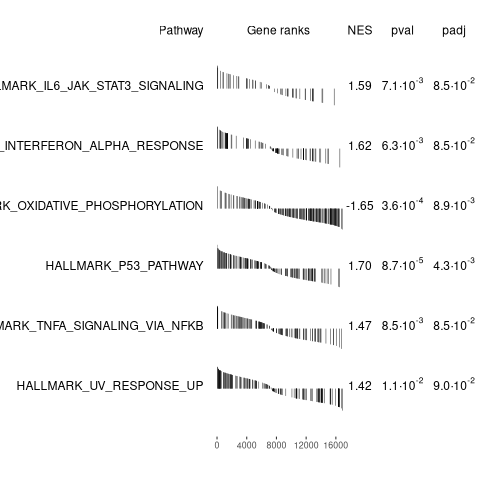

In [280]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

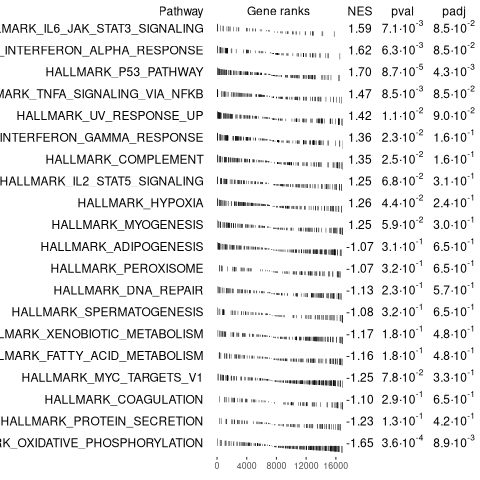

In [281]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [282]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

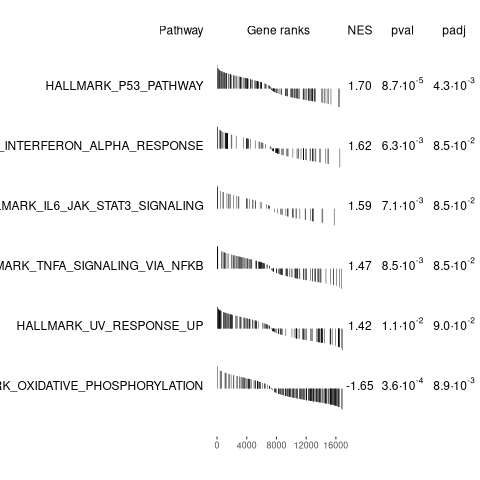

In [283]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [284]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

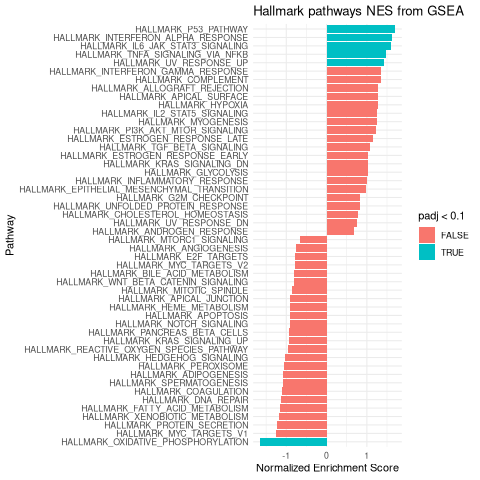

In [285]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [286]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 HALLMARK_P53_PATHWAY               0.00433  1.70   156
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 0.00890 -1.65   182
3 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.0847   1.62    70
4 HALLMARK_IL6_JAK_STAT3_SIGNALING   0.0847   1.59    52
5 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.0847   1.47   133
6 HALLMARK_UV_RESPONSE_UP            0.0902   1.42   128


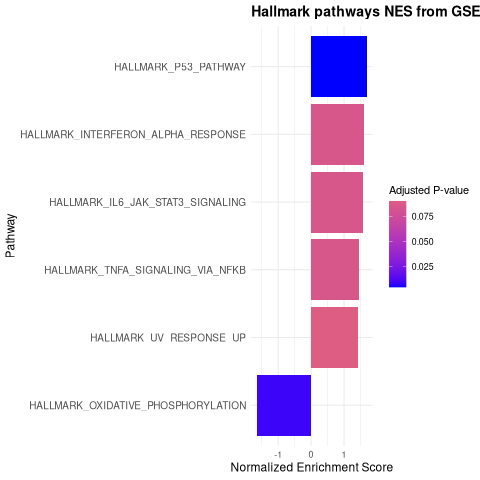

In [287]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

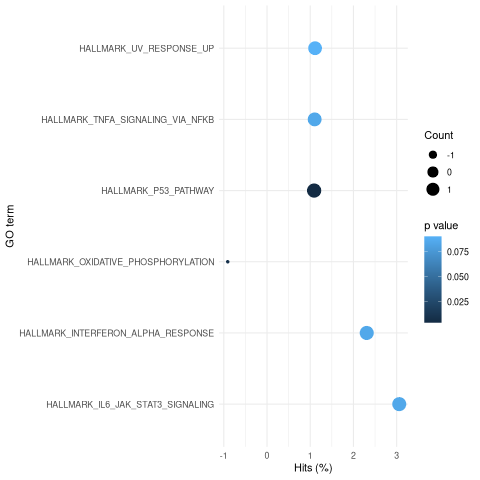

In [288]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [289]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 HALLMARK_P53_PATHWAY               0.00433  1.70   156
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 0.00890 -1.65   182
3 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.0847   1.62    70
4 HALLMARK_IL6_JAK_STAT3_SIGNALING   0.0847   1.59    52
5 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.0847   1.47   133
6 HALLMARK_UV_RESPONSE_UP            0.0902   1.42   128


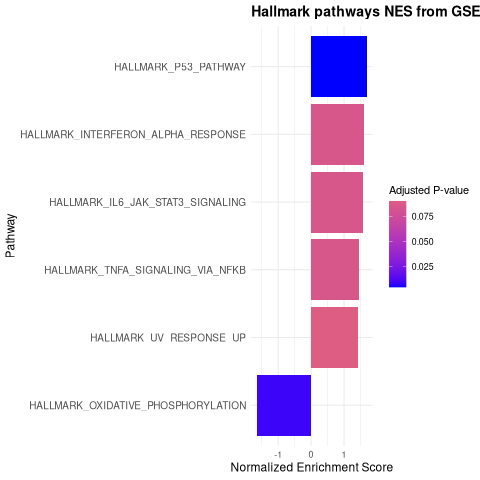

In [290]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [291]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                      padj   NES  size
  <chr>                       <dbl> <dbl> <int>
1 P53_PATHWAY               0.00433  1.70   156
2 OXIDATIVE_PHOSPHORYLATION 0.00890 -1.65   182
3 INTERFERON_ALPHA_RESPONSE 0.0847   1.62    70
4 IL6_JAK_STAT3_SIGNALING   0.0847   1.59    52
5 TNFA_SIGNALING_VIA_NFKB   0.0847   1.47   133
6 UV_RESPONSE_UP            0.0902   1.42   128


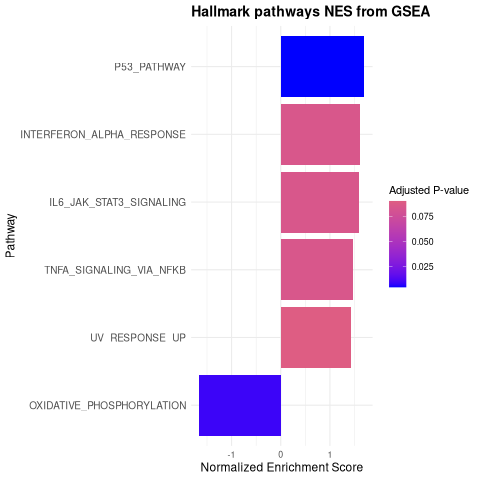

In [292]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

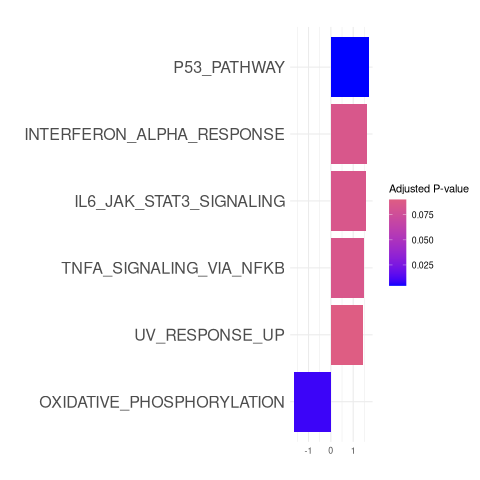

In [293]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_CAL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [294]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [295]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore.csv")

In [296]:
%%R
unique(fgsea_MOL2_significant$pathway)

[1] "HALLMARK_IL6_JAK_STAT3_SIGNALING"   "HALLMARK_INTERFERON_ALPHA_RESPONSE"
[3] "HALLMARK_OXIDATIVE_PHOSPHORYLATION" "HALLMARK_P53_PATHWAY"              
[5] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"   "HALLMARK_UV_RESPONSE_UP"           


In [298]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "CSF1"     "IFIH1"    "EIF2AK2"  "IRF7"     "PARP9"    "GBP2"    
 [7] "HELZ2"    "ADAR"     "PSME2"    "NCOA7"    "TMEM140"  "SLC25A28"
[13] "SP110"    "TRIM26"   "NUB1"     "MVB12A"  


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CIL

In [299]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_CILvWM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

      gene   logFC_WM         se       pvalue convergence pdHess     logLik
1  FAM107A -4.9213151 0.55717781 1.022926e-18           0   TRUE  -86.64067
2    GRIA3  0.5300134 0.06621234 1.197065e-15           0   TRUE -159.49892
3   ABHD10 -0.3166909 0.04438046 9.621229e-13           0   TRUE -110.08430
4 HNRNPUL1 -0.4909349 0.06925633 1.354120e-12           0   TRUE -144.51349
5     GRM7  1.8710338 0.26501083 1.662434e-12           0   TRUE -150.76568
6     DLG1  0.4246605 0.06070647 2.646762e-12           0   TRUE -226.28017
       AIC error          FDR status
1 191.2813    NA 1.886071e-14     OK
2 336.9978    NA 5.517871e-12     OK
3 238.1686    NA 2.534232e-09     OK
4 307.0270    NA 3.120907e-09     OK
5 319.5314    NA 3.405773e-09     OK
6 470.5603    NA 4.880100e-09     OK


In [301]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [302]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 492
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
167    GBP2 -5.290512 1.1343402 3.101889e-06           0   TRUE -106.37611
1   FAM107A -4.921315 0.5571778 1.022926e-18           0   TRUE  -86.64067
16      FOS -4.798065 0.7731079 5.427980e-10           0   TRUE -140.41583
532    EMP1 -4.730335 1.2177997 1.026128e-04           0   TRUE  -85.42937
560   TIMP1 -4.482748 1.1708222 1.288123e-04           0   TRUE  -61.05275
704   ARL4C -4.442926 1.2213557 2.750830e-04           0   TRUE  -52.57624
         AIC error          FDR status logFC_rev
167 230.7522    NA 2.873932e-04     OK  5.290512
1   191.2813    NA 1.886071e-14     OK  4.921315
16  298.8317    NA 5.016885e-07     OK  4.798065
532 188.8587    NA 3.096523e-03     OK  4.730335
560 140.1055    NA 3.692659e-03     OK  4.482748
704 123.1525    NA 6.284981e-03     OK  4.442926


In [303]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 524
          gene logFC_WM        se       pvalue convergence pdHess     logLik
552 AL160272.2 2.859747 0.7419611 1.160574e-04           0   TRUE  -77.85022
198     AHNAK2 2.676891 0.5867669 5.064382e-06           0   TRUE  -94.84760
204      CHRM5 2.488594 0.5470801 5.393569e-06           0   TRUE -181.58615
139 AC114485.1 2.309570 0.4817186 1.631316e-06           0   TRUE -142.17829
178     GPR158 2.121135 0.4571482 3.485306e-06           0   TRUE -166.71979
423      CHST8 2.094376 0.5150557 4.776331e-05           0   TRUE -107.39980
         AIC error          FDR status logFC_rev
552 173.7004    NA 0.0033805142     OK -2.859747
198 207.6952    NA 0.0003971386     OK -2.676891
204 381.1723    NA 0.0004143609     OK -2.488594
139 302.3566    NA 0.0001834037     OK -2.309570
178 351.4396    NA 0.0003063402     OK -2.121135
423 232.7996    NA 0.0018195453     OK -2.094376


In [304]:
%%R

dim(df)

[1] 15952    12


In [305]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "FAM107A"  "GRIA3"    "ABHD10"   "HNRNPUL1" "GRM7"     "DLG1"    


In [306]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [307]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 15951    12


In [308]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 15951"
[1] "Range of Z-scores: -8 to 8.83"
   FAM107A     ABHD10   HNRNPUL1      CEBPD       ASB4 AC008840.1        FOS 
  8.832576   7.135819   7.088665   6.599361   6.581870   6.411424   6.206204 
  ZDHHC11B   PSORS1C1       PID1 
  6.097868   6.088203   6.057244 


In [309]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


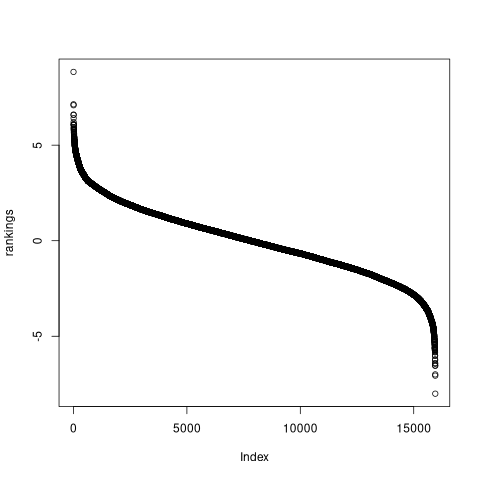

In [310]:
%%R

plot(rankings)

In [311]:
%%R

max(rankings)

[1] 8.832576


In [312]:
%%R

min(rankings)

[1] -8.004753


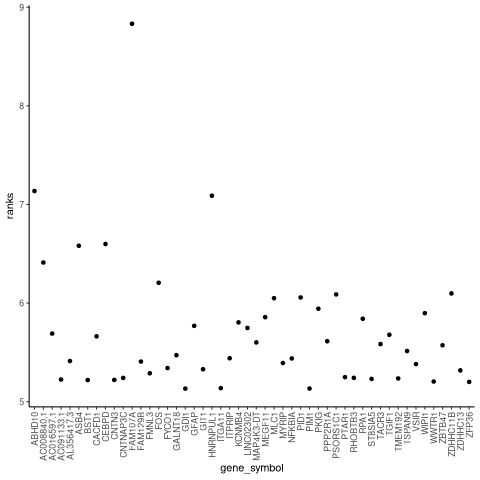

In [313]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [314]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [315]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 6.281800e-01 7.540444e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.351889e-01 2.638809e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 1.477733e-01 2.638809e-01
 4:                      HALLMARK_ANGIOGENESIS 6.719682e-01 7.636002e-01
 5:                   HALLMARK_APICAL_JUNCTION 1.590457e-01 2.742168e-01
 6:                    HALLMARK_APICAL_SURFACE 1.459144e-01 2.638809e-01
 7:                         HALLMARK_APOPTOSIS 1.062299e-02 3.793925e-02
 8:              HALLMARK_BILE_ACID_METABOLISM 9.921569e-01 9.921569e-01
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 2.493456e-02 7.792049e-02
10:                       HALLMARK_COAGULATION 4.158215e-01 5.619209e-01
11:                        HALLMARK_COMPLEMENT 1.956014e-03 8.150058e-03
12:                        HALLMARK_DNA_REPAIR 7.61

In [316]:
%%R

dim(fgsea_res)

[1] 50  8


In [317]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_CILvWM_GvC_all.csv")

In [318]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 16  8


In [319]:
%%R

head(fgsea_MOL2_significant)

                            pathway         pval         padj   log2err
                             <char>        <num>        <num>     <num>
1:               HALLMARK_APOPTOSIS 1.062299e-02 0.0379392532 0.3807304
2: HALLMARK_CHOLESTEROL_HOMEOSTASIS 2.493456e-02 0.0779204932 0.3524879
3:              HALLMARK_COMPLEMENT 1.956014e-03 0.0081500576 0.4317077
4:             HALLMARK_E2F_TARGETS 5.237573e-05 0.0008729288 0.5573322
5: HALLMARK_ESTROGEN_RESPONSE_EARLY 8.621196e-04 0.0042601203 0.4772708
6:  HALLMARK_ESTROGEN_RESPONSE_LATE 1.669145e-04 0.0013909541 0.5188481
          ES      NES  size                                leadingEdge
       <num>    <num> <int>                                     <list>
1: 0.3073048 1.467514   112    BIRC3,GNA15,EMP1,TIMP1,CCND1,TGFBR3,...
2: 0.3436339 1.478389    64 LGMN,TMEM97,TRIB3,HSD17B7,ANTXR2,PCYT2,...
3: 0.3249412 1.585599   130     PIM1,L3MBTL4,CR1,KCNIP3,ZEB1,TIMP1,...
4: 0.3599093 1.799785   152      RPA1,CDCA8,POLE,TP53,NUP205,ATAD2,..

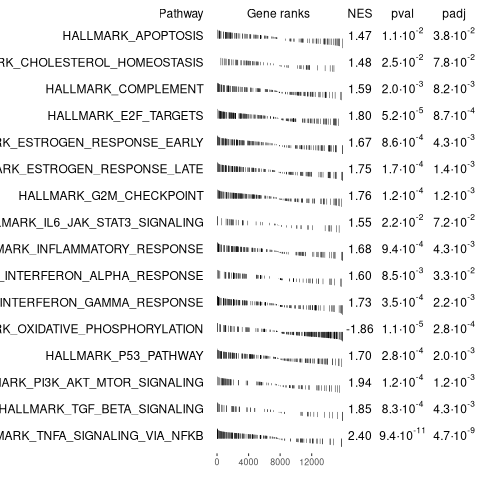

In [320]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

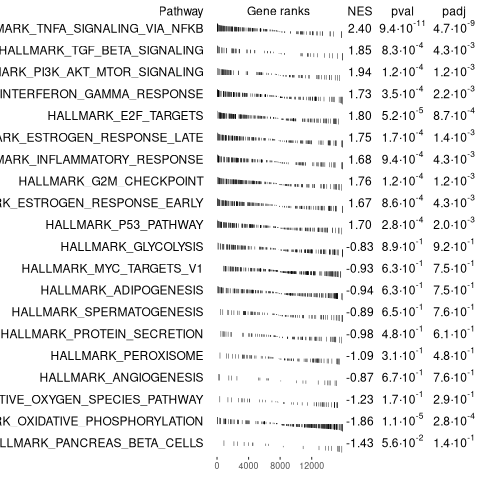

In [321]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [322]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

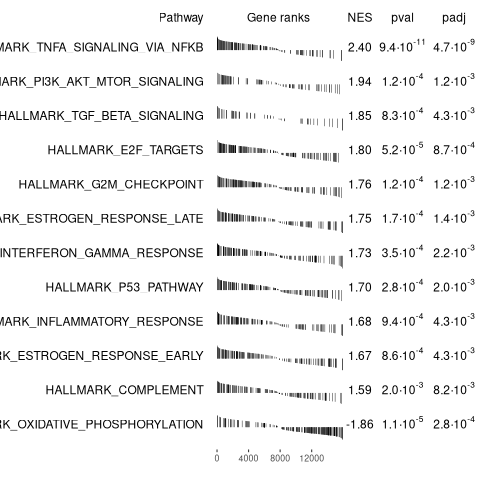

In [323]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [324]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

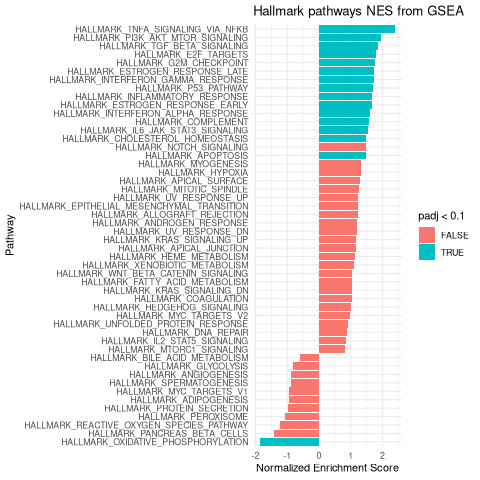

In [325]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [326]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                     padj   NES  size
  <chr>                                      <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.00000000472  2.40   140
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 0.000284      -1.86   170
3 HALLMARK_E2F_TARGETS               0.000873       1.80   152
4 HALLMARK_PI3K_AKT_MTOR_SIGNALING   0.00119        1.94    80
5 HALLMARK_G2M_CHECKPOINT            0.00119        1.76   148
6 HALLMARK_ESTROGEN_RESPONSE_LATE    0.00139        1.75   130


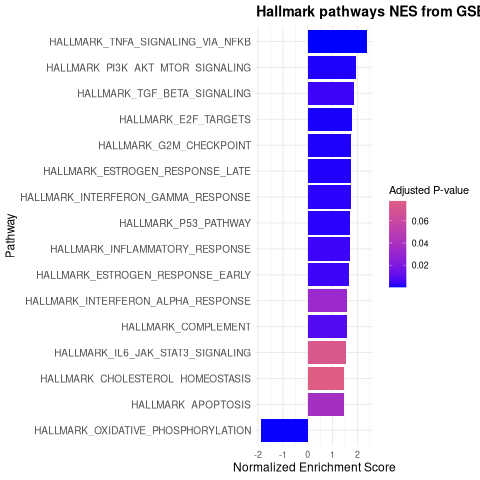

In [327]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

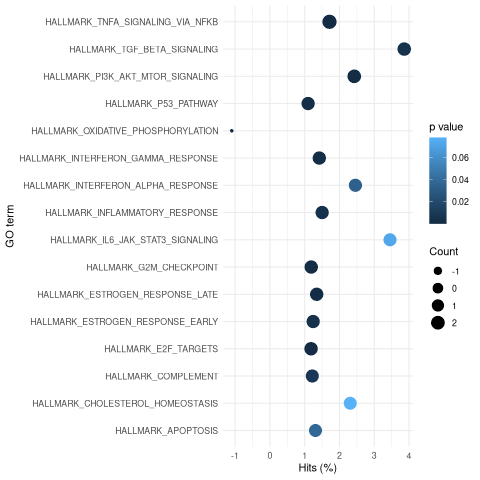

In [328]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [329]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                     padj   NES  size
  <chr>                                      <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   0.00000000472  2.40   140
2 HALLMARK_OXIDATIVE_PHOSPHORYLATION 0.000284      -1.86   170
3 HALLMARK_E2F_TARGETS               0.000873       1.80   152
4 HALLMARK_PI3K_AKT_MTOR_SIGNALING   0.00119        1.94    80
5 HALLMARK_G2M_CHECKPOINT            0.00119        1.76   148
6 HALLMARK_ESTROGEN_RESPONSE_LATE    0.00139        1.75   130


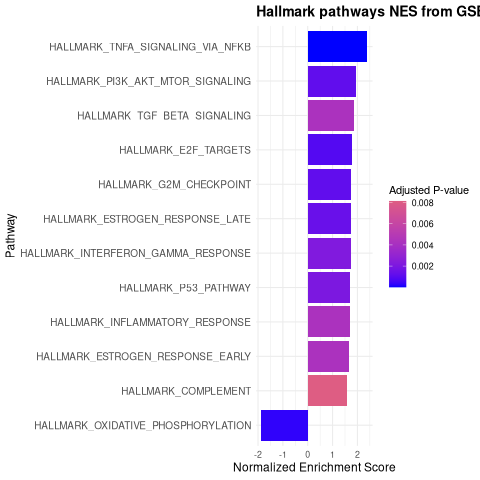

In [330]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [331]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                            padj   NES  size
  <chr>                             <dbl> <dbl> <int>
1 TNFA_SIGNALING_VIA_NFKB   0.00000000472  2.40   140
2 OXIDATIVE_PHOSPHORYLATION 0.000284      -1.86   170
3 E2F_TARGETS               0.000873       1.80   152
4 PI3K_AKT_MTOR_SIGNALING   0.00119        1.94    80
5 G2M_CHECKPOINT            0.00119        1.76   148
6 ESTROGEN_RESPONSE_LATE    0.00139        1.75   130


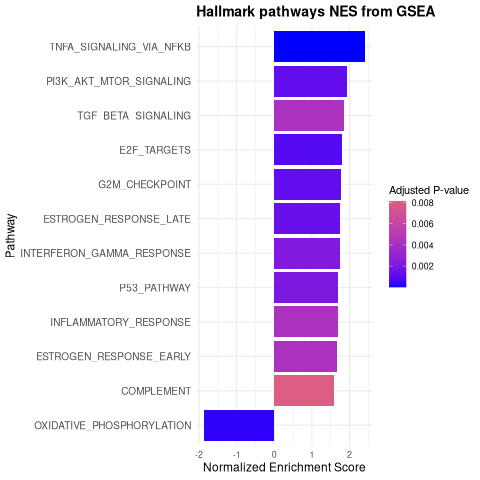

In [332]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

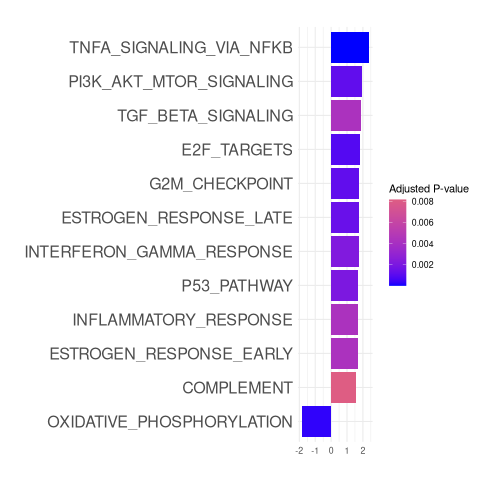

In [333]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_CIL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [334]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [335]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore.csv")

In [336]:
%%R
unique(fgsea_MOL2_significant$pathway)

 [1] "HALLMARK_APOPTOSIS"                 "HALLMARK_CHOLESTEROL_HOMEOSTASIS"  
 [3] "HALLMARK_COMPLEMENT"                "HALLMARK_E2F_TARGETS"              
 [5] "HALLMARK_ESTROGEN_RESPONSE_EARLY"   "HALLMARK_ESTROGEN_RESPONSE_LATE"   
 [7] "HALLMARK_G2M_CHECKPOINT"            "HALLMARK_IL6_JAK_STAT3_SIGNALING"  
 [9] "HALLMARK_INFLAMMATORY_RESPONSE"     "HALLMARK_INTERFERON_ALPHA_RESPONSE"
[11] "HALLMARK_INTERFERON_GAMMA_RESPONSE" "HALLMARK_OXIDATIVE_PHOSPHORYLATION"
[13] "HALLMARK_P53_PATHWAY"               "HALLMARK_PI3K_AKT_MTOR_SIGNALING"  
[15] "HALLMARK_TGF_BETA_SIGNALING"        "HALLMARK_TNFA_SIGNALING_VIA_NFKB"  


In [337]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "CEBPD"    "FOS"      "TGIF1"    "NFKBIA"   "ZFP36"    "SOCS3"   
 [7] "BIRC3"    "TRAF1"    "KLF10"    "PDLIM5"   "KLF9"     "CCND1"   
[13] "TRIP10"   "BCL6"     "CDKN1A"   "FOSL2"    "SERPINE1" "GFPT2"   
[19] "SGK1"     "LITAF"    "SPSB1"    "NR4A1"    "CEBPB"    "CLCF1"   
[25] "GADD45B"  "PLK2"     "BMP2"     "KYNU"     "NINJ1"    "IRS2"    
[31] "MAP2K3"   "TNC"      "IL6ST"    "JUNB"     "IL15RA"   "ICOSLG"  
[37] "RNF19B"   "MAFF"     "PMEPA1"   "KLF6"     "PFKFB3"   "RELA"    
[43] "TRIB1"    "LDLR"     "BCL3"     "PLAUR"    "GCH1"     "IER5"    
[49] "EGR1"     "CFLAR"    "CSF1"     "DRAM1"    "TNIP2"    "FOSB"    
[55] "ATP2B1"   "EFNA1"    "B4GALT1"  "GADD45A"  "KDM6B"    "FOSL1"   
[61] "SOD2"     "RIPK2"    "BHLHE40"  "PHLDA1"   "B4GALT5"  "REL"     
[67] "CD83"     "TSC22D1"  "PPP1R15A" "GEM"      "STAT5A"   "TNFAIP6" 
[73] "MARCKS"   "NFAT5"    "ZC3H12A" 


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# RL_MOL

In [338]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_RLvWM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

        gene  logFC_WM        se       pvalue convergence pdHess     logLik
1    ST8SIA5 -1.703685 0.1757233 3.158016e-22           0   TRUE -145.76223
2      CLVS2 -3.858996 0.4196768 3.744289e-20           0   TRUE  -90.69794
3     DDX60L -1.171806 0.1386648 2.897042e-17           0   TRUE  -82.64436
4   ARHGAP24 -2.431437 0.2972131 2.819908e-16           0   TRUE -119.66525
5 AC008840.1 -1.065743 0.1314502 5.163720e-16           0   TRUE  -83.31787
6 AL356417.3 -1.063240 0.1329804 1.290832e-15           0   TRUE  -78.67850
       AIC error          FDR status
1 309.5245    NA 2.986220e-18     OK
2 199.3959    NA 2.360399e-16     OK
3 183.2887    NA 1.369721e-13     OK
4 257.3305    NA 1.066602e-12     OK
5 184.6357    NA 1.627604e-12     OK
6 175.3570    NA 3.487458e-12     OK


In [339]:
%%R

df <- df %>% mutate(logFC_rev = logFC_WM * -1)

In [340]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 420
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
18  FAM107A -6.850994 1.0316728 3.122704e-11           0   TRUE  -57.78305
45      FOS -5.351660 0.8985550 2.587219e-09           0   TRUE -122.82416
109    GBP2 -4.935687 0.9493011 2.000568e-07           0   TRUE  -92.95005
484   KLF10 -4.566045 1.1228699 4.774373e-05           0   TRUE  -59.17112
506     VIM -4.259439 1.0519593 5.142520e-05           0   TRUE  -54.04664
706   TIMP1 -3.905782 1.0316917 1.532126e-04           0   TRUE  -45.50765
         AIC error          FDR status logFC_rev
18  133.5661    NA 2.684389e-08     OK  6.850994
45  263.6483    NA 9.231978e-07     OK  5.351660
109 203.9001    NA 3.126838e-05     OK  4.935687
484 136.3422    NA 1.694052e-03     OK  4.566045
506 126.0933    NA 1.746795e-03     OK  4.259439
706 109.0153    NA 3.724367e-03     OK  3.905782


In [341]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 625
          gene logFC_WM        se       pvalue convergence pdHess     logLik
413  LINC01515 4.639852 1.1122074 3.022682e-05           0   TRUE -102.15651
754      FGFR3 3.780415 1.0103513 1.827916e-04           0   TRUE  -45.42089
1291    TCEAL5 3.593220 1.0906605 9.858451e-04           0   TRUE  -73.76164
783   ADAMTS18 3.475205 0.9373284 2.092625e-04           0   TRUE -179.34731
61       FLRT2 3.424970 0.5890498 6.085230e-09           0   TRUE  -68.44706
339       DPP4 3.382809 0.7863929 1.695101e-05           0   TRUE  -50.56720
          AIC error          FDR status logFC_rev
413  222.3130    NA 1.255644e-03     OK -4.639852
754  108.8418    NA 4.159308e-03     OK -3.780415
1291 165.5233    NA 1.330752e-02     OK -3.593220
783  376.6946    NA 4.591150e-03     OK -3.475205
61   154.8941    NA 1.667882e-06     OK -3.424970
339  119.1344    NA 8.594571e-04     OK -3.382809


In [342]:
%%R

dim(df)

[1] 17208    12


In [343]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "ST8SIA5"    "CLVS2"      "DDX60L"     "ARHGAP24"   "AC008840.1"
[6] "AL356417.3"


In [344]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [347]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 17207    12


In [348]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 17207"
[1] "Range of Z-scores: -7.69 to 9.7"
   ST8SIA5      CLVS2     DDX60L   ARHGAP24 AC008840.1 AL356417.3       VSIR 
  9.695270   9.195162   8.450642   8.180789   8.107582   7.995467   7.920426 
   RHOBTB3     SH3RF3      SF3B4 
  7.123278   7.051074   7.024701 


In [349]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


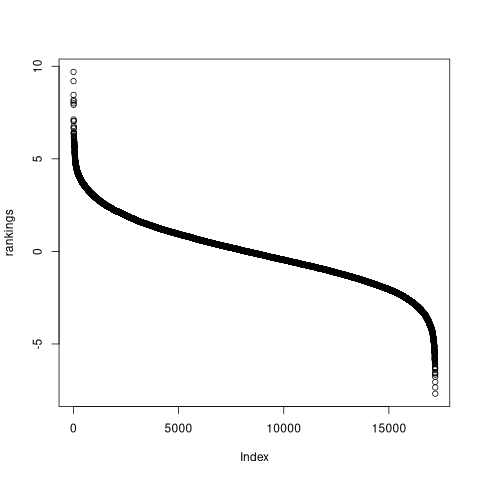

In [350]:
%%R

plot(rankings)

In [351]:
%%R

max(rankings)

[1] 9.69527


In [352]:
%%R

min(rankings)

[1] -7.685252


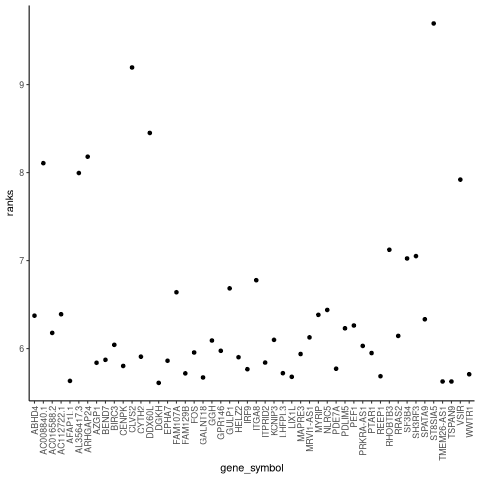

In [353]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## set up gene lists

In [354]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [355]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 5.001898e-02 1.000380e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.863118e-01 2.658420e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 1.180261e-02 2.950654e-02
 4:                      HALLMARK_ANGIOGENESIS 6.653226e-01 7.231767e-01
 5:                   HALLMARK_APICAL_JUNCTION 1.303462e-01 1.974943e-01
 6:                    HALLMARK_APICAL_SURFACE 2.763419e-01 3.542845e-01
 7:                         HALLMARK_APOPTOSIS 9.955637e-05 4.148182e-04
 8:              HALLMARK_BILE_ACID_METABOLISM 9.293893e-01 9.293893e-01
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 8.386378e-04 2.795459e-03
10:                       HALLMARK_COAGULATION 2.117202e-01 2.785792e-01
11:                        HALLMARK_COMPLEMENT 1.592513e-02 3.619348e-02
12:                        HALLMARK_DNA_REPAIR 9.26

In [356]:
%%R

dim(fgsea_res)

[1] 50  8


In [357]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_RL_GvC_all.csv")

In [358]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 24  8


In [359]:
%%R

head(fgsea_MOL4_significant)

                            pathway         pval         padj   log2err
                             <char>        <num>        <num>     <num>
1:       HALLMARK_ANDROGEN_RESPONSE 1.180261e-02 2.950654e-02 0.3807304
2:               HALLMARK_APOPTOSIS 9.955637e-05 4.148182e-04 0.5384341
3: HALLMARK_CHOLESTEROL_HOMEOSTASIS 8.386378e-04 2.795459e-03 0.4772708
4:              HALLMARK_COMPLEMENT 1.592513e-02 3.619348e-02 0.3524879
5:             HALLMARK_E2F_TARGETS 3.910467e-11 9.776168e-10 0.8513391
6: HALLMARK_ESTROGEN_RESPONSE_EARLY 1.413930e-03 4.418530e-03 0.4550599
          ES      NES  size                                leadingEdge
       <num>    <num> <int>                                     <list>
1: 0.3637198 1.556852    83 PDLIM5,AZGP1,GNAI3,RPS6KA3,SORD,HMGCS1,...
2: 0.4109242 1.825565   109       BIRC3,BMP2,RARA,BCL10,RELA,ISG20,...
3: 0.4488738 1.827313    64 HSD17B7,TMEM97,FDFT1,HMGCS1,HMGCR,LDLR,...
4: 0.3138779 1.434671   134      KCNIP3,DGKH,GNAI3,ZFPM2,GNB2,PIM1,..

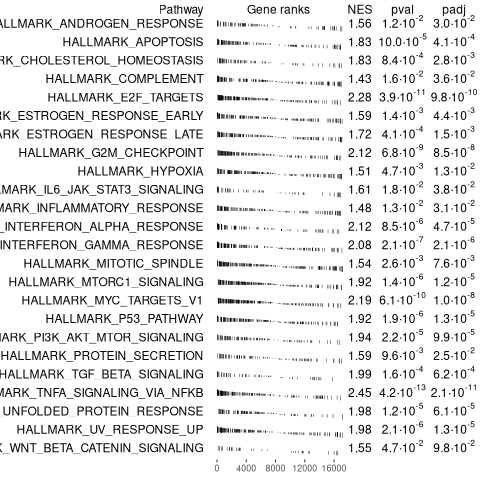

In [360]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

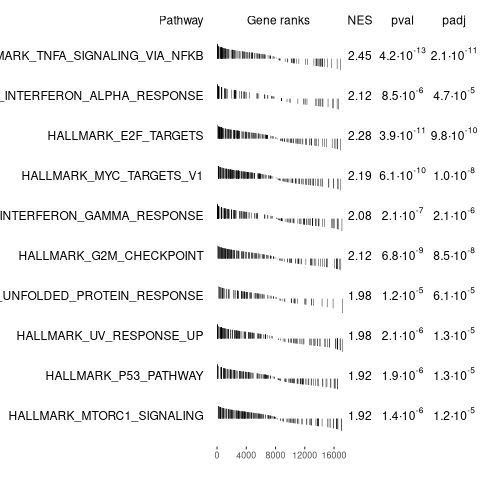

In [361]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [362]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

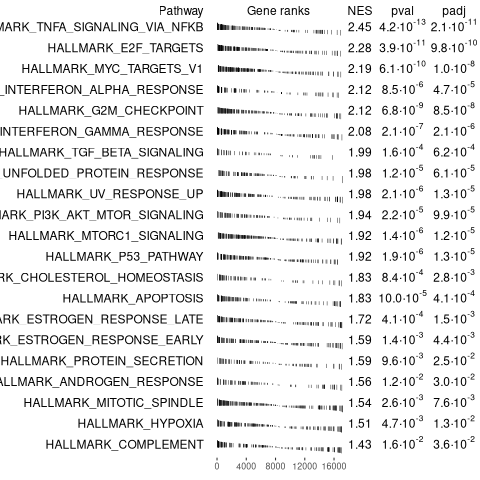

In [363]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [364]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [365]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   2.08e-11  2.45   142
2 HALLMARK_E2F_TARGETS               9.78e-10  2.28   161
3 HALLMARK_MYC_TARGETS_V1            1.01e- 8  2.19   177
4 HALLMARK_G2M_CHECKPOINT            8.49e- 8  2.12   151
5 HALLMARK_INTERFERON_GAMMA_RESPONSE 2.10e- 6  2.08   129
6 HALLMARK_MTORC1_SIGNALING          1.19e- 5  1.92   171


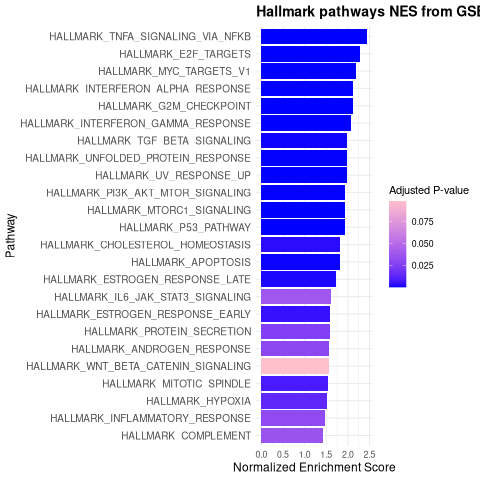

In [366]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

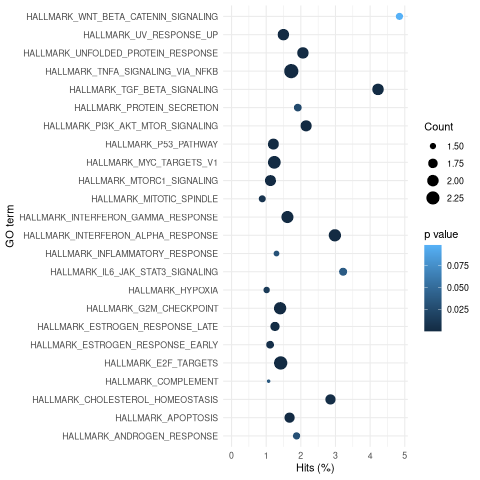

In [367]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [368]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 HALLMARK_TNFA_SIGNALING_VIA_NFKB   2.08e-11  2.45   142
2 HALLMARK_E2F_TARGETS               9.78e-10  2.28   161
3 HALLMARK_MYC_TARGETS_V1            1.01e- 8  2.19   177
4 HALLMARK_G2M_CHECKPOINT            8.49e- 8  2.12   151
5 HALLMARK_INTERFERON_GAMMA_RESPONSE 2.10e- 6  2.08   129
6 HALLMARK_MTORC1_SIGNALING          1.19e- 5  1.92   171


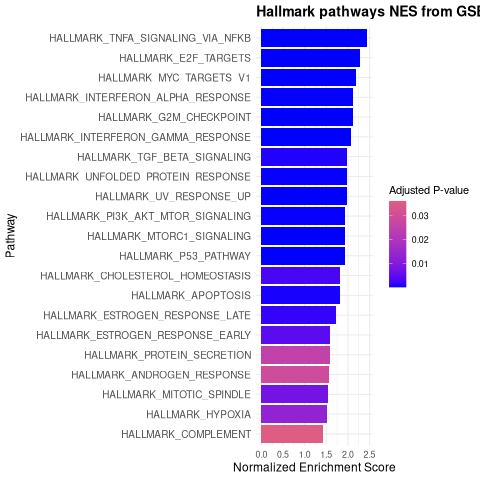

In [369]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


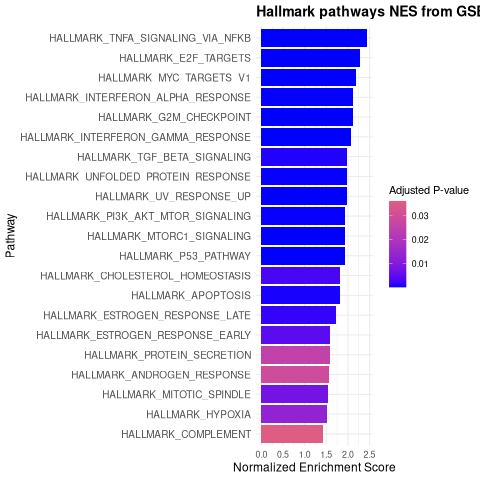

In [370]:
%%R

# Create the ggplot
plot <- # Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_RL_reduced_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [371]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                       padj   NES  size
  <chr>                        <dbl> <dbl> <int>
1 TNFA_SIGNALING_VIA_NFKB   2.08e-11  2.45   142
2 E2F_TARGETS               9.78e-10  2.28   161
3 MYC_TARGETS_V1            1.01e- 8  2.19   177
4 G2M_CHECKPOINT            8.49e- 8  2.12   151
5 INTERFERON_GAMMA_RESPONSE 2.10e- 6  2.08   129
6 MTORC1_SIGNALING          1.19e- 5  1.92   171


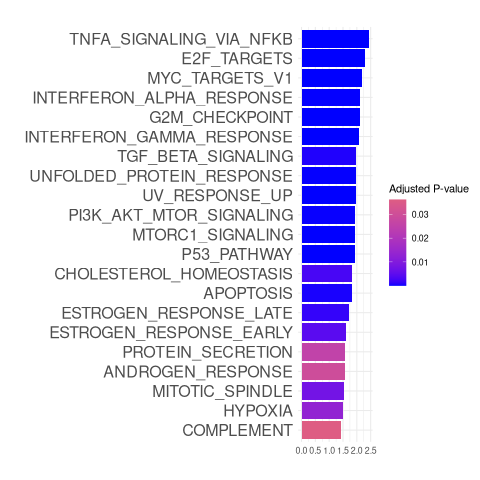

In [372]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_RL_reduced_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [373]:
%%R

class(fgsea_MOL4_significant)

[1] "data.table" "data.frame"


In [374]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [375]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_RL_all_glmm_zscore.csv")

In [376]:
%%R
unique(fgsea_MOL4_significant$pathway)

 [1] "HALLMARK_ANDROGEN_RESPONSE"          "HALLMARK_APOPTOSIS"                 
 [3] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"    "HALLMARK_COMPLEMENT"                
 [5] "HALLMARK_E2F_TARGETS"                "HALLMARK_ESTROGEN_RESPONSE_EARLY"   
 [7] "HALLMARK_ESTROGEN_RESPONSE_LATE"     "HALLMARK_G2M_CHECKPOINT"            
 [9] "HALLMARK_HYPOXIA"                    "HALLMARK_IL6_JAK_STAT3_SIGNALING"   
[11] "HALLMARK_INFLAMMATORY_RESPONSE"      "HALLMARK_INTERFERON_ALPHA_RESPONSE" 
[13] "HALLMARK_INTERFERON_GAMMA_RESPONSE"  "HALLMARK_MITOTIC_SPINDLE"           
[15] "HALLMARK_MTORC1_SIGNALING"           "HALLMARK_MYC_TARGETS_V1"            
[17] "HALLMARK_P53_PATHWAY"                "HALLMARK_PI3K_AKT_MTOR_SIGNALING"   
[19] "HALLMARK_PROTEIN_SECRETION"          "HALLMARK_TGF_BETA_SIGNALING"        
[21] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"    "HALLMARK_UNFOLDED_PROTEIN_RESPONSE" 
[23] "HALLMARK_UV_RESPONSE_UP"             "HALLMARK_WNT_BETA_CATENIN_SIGNALING"


In [377]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "NLRC5"    "HELZ2"    "IRF9"     "SOCS3"    "HLA-B"    "NFKBIA"  
 [7] "PML"      "ISG20"    "PIM1"     "PSMB9"    "HERC6"    "BTG1"    
[13] "DDX60"    "PSMB8"    "IRF7"     "TAP1"     "ZNFX1"    "DDX58"   
[19] "IFIH1"    "TAPBP"    "ADAR"     "IRF1"     "OGFR"     "NMI"     
[25] "RIPK2"    "STAT3"    "TNFAIP6"  "PSMB2"    "STAT1"    "IL10RA"  
[31] "NOD1"     "TXNIP"    "HLA-A"    "LATS2"    "TOR1B"    "CIITA"   
[37] "SP110"    "RBCK1"    "SLC25A28" "IRF4"     "CD40"     "IFI35"   
[43] "TRIM25"   "PLA2G4A"  "SAMHD1"   "PSME1"    "ARID5B"   "PELI1"   
[49] "APOL6"    "B2M"      "CDKN1A"   "PARP14"   "NFKB1"    "CD38"    
[55] "UBE2L6"  


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CREATE A COMBINED HEATMAP-- NEW NES colored

In [59]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
NAWM_df <- fread("./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore.csv")
AL_df <- fread("./files/filtered_fgseaResSignificant_AL_all_glmm_zscore.csv")
CAL_df <- fread("./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore.csv")
CIL_df <- fread("./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore.csv")
RL_df <- fread("./files/filtered_fgseaResSignificant_RL_all_glmm_zscore.csv")

In [60]:
%%R
print(dim(NAWM_df))
print(dim(AL_df))
print(dim(CAL_df))
print(dim(CIL_df))
print(dim(RL_df))

[1] 20  8
[1] 9 8
[1] 6 8
[1] 12  8
[1] 24  8


In [61]:
%%R
# For detailed differences in column names (if any)
list_columns <- list(
    NAWM_df = colnames(NAWM_df),
    AL_df = colnames(AL_df),
    CAL_df = colnames(CAL_df),
    CIL_df = colnames(CIL_df),
    RL_df = colnames(RL_df)
)

print(list_columns)

$NAWM_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$AL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$CAL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$CIL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$RL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"



In [62]:
%%R

# Subset the data frames to include only pathway, padj, NES, and size
subset_columns <- c("pathway", "NES", "padj")

NAWM_subset <- NAWM_df[, ..subset_columns]
AL_subset <- AL_df[, ..subset_columns]
CAL_subset <- CAL_df[, ..subset_columns]
CIL_subset <- CIL_df[, ..subset_columns]
RL_subset <- RL_df[, ..subset_columns]

In [63]:
%%R

# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(NAWM_df$pathway, AL_df$pathway, CAL_df$pathway, CIL_df$pathway, RL_df$pathway))

# Verify the unique pathways
print(head(all_pathways))

# Check the total number of unique pathways
length(all_pathways)

[1] "HALLMARK_APICAL_JUNCTION"                  
[2] "HALLMARK_APOPTOSIS"                        
[3] "HALLMARK_COMPLEMENT"                       
[4] "HALLMARK_DNA_REPAIR"                       
[5] "HALLMARK_E2F_TARGETS"                      
[6] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[1] 31


In [64]:
%%R
# Function to ensure each data frame includes all pathways and fills missing ones with NaN
fill_missing_pathways <- function(df, all_pathways) {
  # Identify pathways that are missing in the current data frame
  missing_pathways <- setdiff(all_pathways, df$pathway)
  
  # Create a data frame with missing pathways, NES and padj set to NaN
  missing_data <- data.frame(pathway = missing_pathways, 
                             NES = rep(NaN, length(missing_pathways)), 
                             padj = rep(NaN, length(missing_pathways)))
  
  # Combine the original data frame with the missing pathways
  df <- rbind(df[, c("pathway", "NES", "padj")], missing_data)
  
  # Sort by pathway to maintain a consistent order
  df <- df[order(df$pathway), ]
  
  return(df)
}

# List of all unique pathways
all_pathways <- unique(c(AL_df$pathway, CAL_df$pathway, CIL_df$pathway, RL_df$pathway))

# Apply the function to all data frames
NAWM_filtered <- fill_missing_pathways(NAWM_subset, all_pathways)
AL_filtered <- fill_missing_pathways(AL_subset, all_pathways)
CAL_filtered <- fill_missing_pathways(CAL_subset, all_pathways)
CIL_filtered <- fill_missing_pathways(CIL_subset, all_pathways)
RL_filtered <- fill_missing_pathways(RL_subset, all_pathways)

In [65]:
%%R
NAWM_filtered$condition <- "NAWM"
AL_filtered$condition <- "AL"
CAL_filtered$condition <- "CAL"
CIL_filtered$condition <- "CIL"
RL_filtered$condition <- "RL"

# Combine all datasets into a single dataframe
combined_df <- rbind(NAWM_filtered, AL_filtered, CAL_filtered, CIL_filtered, RL_filtered)

# Verify the structure
head(combined_df)

                            pathway       NES        padj condition
                             <char>     <num>       <num>    <char>
1:       HALLMARK_ANDROGEN_RESPONSE       NaN         NaN      NAWM
2:         HALLMARK_APICAL_JUNCTION -1.329261 0.082969525      NAWM
3:               HALLMARK_APOPTOSIS  1.398001 0.056179939      NAWM
4: HALLMARK_CHOLESTEROL_HOMEOSTASIS       NaN         NaN      NAWM
5:              HALLMARK_COMPLEMENT  1.758760 0.000300747      NAWM
6:              HALLMARK_DNA_REPAIR  1.394834 0.056179939      NAWM


In [66]:
%%R
dim(combined_df)

[1] 131   4


In [67]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
combined_df$pathway <- gsub("^HALLMARK_", "", combined_df$pathway)

# View the updated heatmap_df
head(combined_df)

                   pathway       NES        padj condition
                    <char>     <num>       <num>    <char>
1:       ANDROGEN_RESPONSE       NaN         NaN      NAWM
2:         APICAL_JUNCTION -1.329261 0.082969525      NAWM
3:               APOPTOSIS  1.398001 0.056179939      NAWM
4: CHOLESTEROL_HOMEOSTASIS       NaN         NaN      NAWM
5:              COMPLEMENT  1.758760 0.000300747      NAWM
6:              DNA_REPAIR  1.394834 0.056179939      NAWM


In [68]:
%%R
head(combined_df)

                   pathway       NES        padj condition
                    <char>     <num>       <num>    <char>
1:       ANDROGEN_RESPONSE       NaN         NaN      NAWM
2:         APICAL_JUNCTION -1.329261 0.082969525      NAWM
3:               APOPTOSIS  1.398001 0.056179939      NAWM
4: CHOLESTEROL_HOMEOSTASIS       NaN         NaN      NAWM
5:              COMPLEMENT  1.758760 0.000300747      NAWM
6:              DNA_REPAIR  1.394834 0.056179939      NAWM


In [69]:
%%R
tail(combined_df)

                      pathway      NES         padj condition
                       <char>    <num>        <num>    <char>
1:          PROTEIN_SECRETION 1.587376 2.534312e-02        RL
2:         TGF_BETA_SIGNALING 1.987070 6.234655e-04        RL
3:    TNFA_SIGNALING_VIA_NFKB 2.448179 2.077330e-11        RL
4:  UNFOLDED_PROTEIN_RESPONSE 1.977335 6.080787e-05        RL
5:             UV_RESPONSE_UP 1.976028 1.289278e-05        RL
6: WNT_BETA_CATENIN_SIGNALING 1.550863 9.842329e-02        RL


In [70]:
%%R

# Transform padj to -log10 for better visualization
combined_df$log_padj <- -log10(combined_df$padj)

In [71]:
%%R

dim(combined_df)

[1] 131   5


In [72]:
%%R

head(combined_df, 20)

                              pathway       NES        padj condition log_padj
                               <char>     <num>       <num>    <char>    <num>
 1:                 ANDROGEN_RESPONSE       NaN         NaN      NAWM      NaN
 2:                   APICAL_JUNCTION -1.329261 0.082969525      NAWM 1.081081
 3:                         APOPTOSIS  1.398001 0.056179939      NAWM 1.250419
 4:           CHOLESTEROL_HOMEOSTASIS       NaN         NaN      NAWM      NaN
 5:                        COMPLEMENT  1.758760 0.000300747      NAWM 3.521799
 6:                        DNA_REPAIR  1.394834 0.056179939      NAWM 1.250419
 7:                       E2F_TARGETS  1.643475 0.001815222      NAWM 2.741070
 8: EPITHELIAL_MESENCHYMAL_TRANSITION  1.392290 0.056179939      NAWM 1.250419
 9:           ESTROGEN_RESPONSE_EARLY       NaN         NaN      NAWM      NaN
10:            ESTROGEN_RESPONSE_LATE  1.339529 0.062686831      NAWM 1.202824
11:             FATTY_ACID_METABOLISM  1.638719 0.00

In addition: Warning message:
Removed 60 rows containing missing values or values outside the scale range
(`geom_point()`). 


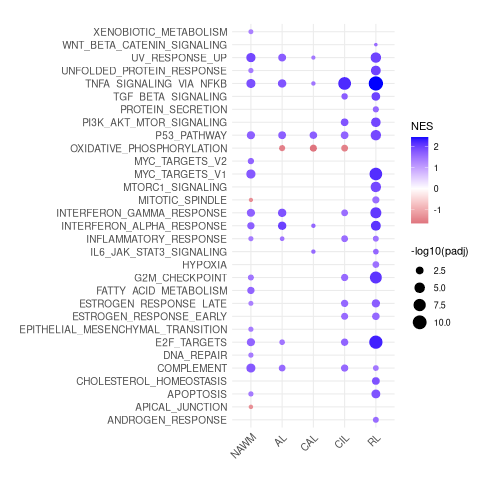

In [73]:
%%R

library(ggplot2)

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("NAWM", "AL", "CAL", "CIL", "RL"))

# Create the dotplot with switched axes and assign to heatmap_plot
heatmap_plot <- ggplot(combined_df, aes(y = pathway, x = condition, size = log_padj, color = NES)) +
  geom_point() +
  scale_color_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10), # Adjust pathway text size for readability
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) + # Adjust condition text
  labs(x = "", y = "", 
       size = "-log10(padj)", color = "NES", 
       title = "")

# Show the plot
print(heatmap_plot)

In [74]:
%%R

# Remove rows with missing or NaN values in `log_padj` or `NES`
filtered_df <- combined_df[!is.na(combined_df$log_padj) & !is.na(combined_df$NES), ]
head(filtered_df)

                             pathway       NES        padj condition log_padj
                              <char>     <num>       <num>    <fctr>    <num>
1:                   APICAL_JUNCTION -1.329261 0.082969525      NAWM 1.081081
2:                         APOPTOSIS  1.398001 0.056179939      NAWM 1.250419
3:                        COMPLEMENT  1.758760 0.000300747      NAWM 3.521799
4:                        DNA_REPAIR  1.394834 0.056179939      NAWM 1.250419
5:                       E2F_TARGETS  1.643475 0.001815222      NAWM 2.741070
6: EPITHELIAL_MESENCHYMAL_TRANSITION  1.392290 0.056179939      NAWM 1.250419


In [75]:
%%R
dim(filtered_df)

[1] 71  5


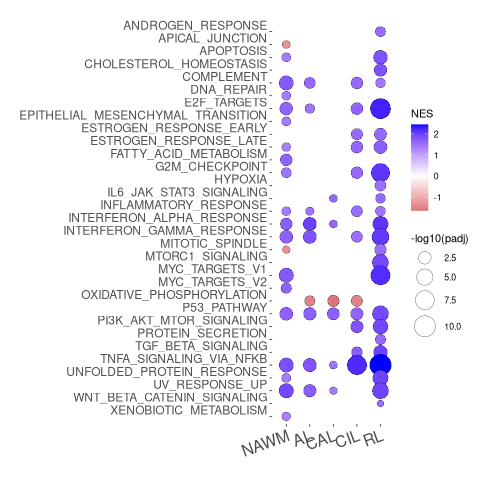

In [76]:
%%R

# Create the dotplot with adjustments
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") + # Add thin black outline to dots
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) + # Increase size of dots (min=3, max=10)
  scale_y_discrete(limits = rev(levels(factor(filtered_df$pathway))),  # Reverse the y-axis order if needed
                   labels = function(x) paste0(x, "\n")) + # Add line breaks for extra vertical space
  theme_minimal() +
  theme(
    panel.grid = element_blank(), # Remove grid lines
    axis.text.y = element_text(size = 12), # Add vertical spacing for y-axis text
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1), # Adjust x-axis text spacing
    axis.ticks = element_line(linewidth = 0.3) # Adjust x-axis ticks with `linewidth`
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Display the plot
print(heatmap_plot)

In [77]:
%%R
print(unique(filtered_df$pathway))

 [1] "APICAL_JUNCTION"                   "APOPTOSIS"                        
 [3] "COMPLEMENT"                        "DNA_REPAIR"                       
 [5] "E2F_TARGETS"                       "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [7] "ESTROGEN_RESPONSE_LATE"            "FATTY_ACID_METABOLISM"            
 [9] "G2M_CHECKPOINT"                    "INFLAMMATORY_RESPONSE"            
[11] "INTERFERON_ALPHA_RESPONSE"         "INTERFERON_GAMMA_RESPONSE"        
[13] "MITOTIC_SPINDLE"                   "MYC_TARGETS_V1"                   
[15] "MYC_TARGETS_V2"                    "P53_PATHWAY"                      
[17] "TNFA_SIGNALING_VIA_NFKB"           "UNFOLDED_PROTEIN_RESPONSE"        
[19] "UV_RESPONSE_UP"                    "XENOBIOTIC_METABOLISM"            
[21] "OXIDATIVE_PHOSPHORYLATION"         "IL6_JAK_STAT3_SIGNALING"          
[23] "ESTROGEN_RESPONSE_EARLY"           "PI3K_AKT_MTOR_SIGNALING"          
[25] "TGF_BETA_SIGNALING"                "ANDROGEN_RESPONSE"                

In [78]:
%%R

# Define the desired order for the pathways
desired_pathway_order <- c(
    "TNFA_SIGNALING_VIA_NFKB",
    "P53_PATHWAY",
    "INTERFERON_ALPHA_RESPONSE",
    "INTERFERON_GAMMA_RESPONSE",
    "E2F_TARGETS",
    "COMPLEMENT",
    "UV_RESPONSE_UP",
    "INFLAMMATORY_RESPONSE",
    "IL6_JAK_STAT3_SIGNALING",
    "APOPTOSIS",
    "G2M_CHECKPOINT",
    "ESTROGEN_RESPONSE_LATE",
    "TGF_BETA_SIGNALING",
    "PI3K_AKT_MTOR_SIGNALING",
    "CHOLESTEROL_HOMEOSTASIS",
    "ESTROGEN_RESPONSE_EARLY",
    "UNFOLDED_PROTEIN_RESPONSE",
    "HYPOXIA",
    "MYC_TARGETS_V1",
    "MYC_TARGETS_V2",
    "DNA_REPAIR",
    "EPITHELIAL_MESENCHYMAL_TRANSITION",
    "FATTY_ACID_METABOLISM",
    "XENOBIOTIC_METABOLISM",
    "MTORC1_SIGNALING",
    "PROTEIN_SECRETION",
    "ANDROGEN_RESPONSE",
    "WNT_BETA_CATENIN_SIGNALING",
    "MITOTIC_SPINDLE",
    "APICAL_JUNCTION",
    "OXIDATIVE_PHOSPHORYLATION"
)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = desired_pathway_order)

# Verify the order
print(levels(filtered_df$pathway))

 [1] "TNFA_SIGNALING_VIA_NFKB"           "P53_PATHWAY"                      
 [3] "INTERFERON_ALPHA_RESPONSE"         "INTERFERON_GAMMA_RESPONSE"        
 [5] "E2F_TARGETS"                       "COMPLEMENT"                       
 [7] "UV_RESPONSE_UP"                    "INFLAMMATORY_RESPONSE"            
 [9] "IL6_JAK_STAT3_SIGNALING"           "APOPTOSIS"                        
[11] "G2M_CHECKPOINT"                    "ESTROGEN_RESPONSE_LATE"           
[13] "TGF_BETA_SIGNALING"                "PI3K_AKT_MTOR_SIGNALING"          
[15] "CHOLESTEROL_HOMEOSTASIS"           "ESTROGEN_RESPONSE_EARLY"          
[17] "UNFOLDED_PROTEIN_RESPONSE"         "HYPOXIA"                          
[19] "MYC_TARGETS_V1"                    "MYC_TARGETS_V2"                   
[21] "DNA_REPAIR"                        "EPITHELIAL_MESENCHYMAL_TRANSITION"
[23] "FATTY_ACID_METABOLISM"             "XENOBIOTIC_METABOLISM"            
[25] "MTORC1_SIGNALING"                  "PROTEIN_SECRETION"                

In [79]:
%%R
# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = reversed_pathway_order)

# Verify the reversed order
print(levels(filtered_df$pathway))

 [1] "OXIDATIVE_PHOSPHORYLATION"         "APICAL_JUNCTION"                  
 [3] "MITOTIC_SPINDLE"                   "WNT_BETA_CATENIN_SIGNALING"       
 [5] "ANDROGEN_RESPONSE"                 "PROTEIN_SECRETION"                
 [7] "MTORC1_SIGNALING"                  "XENOBIOTIC_METABOLISM"            
 [9] "FATTY_ACID_METABOLISM"             "EPITHELIAL_MESENCHYMAL_TRANSITION"
[11] "DNA_REPAIR"                        "MYC_TARGETS_V2"                   
[13] "MYC_TARGETS_V1"                    "HYPOXIA"                          
[15] "UNFOLDED_PROTEIN_RESPONSE"         "ESTROGEN_RESPONSE_EARLY"          
[17] "CHOLESTEROL_HOMEOSTASIS"           "PI3K_AKT_MTOR_SIGNALING"          
[19] "TGF_BETA_SIGNALING"                "ESTROGEN_RESPONSE_LATE"           
[21] "G2M_CHECKPOINT"                    "APOPTOSIS"                        
[23] "IL6_JAK_STAT3_SIGNALING"           "INFLAMMATORY_RESPONSE"            
[25] "UV_RESPONSE_UP"                    "COMPLEMENT"                       

In [80]:
%%R

# Dictionary to format pathway names
pathway_name_format <- list(
    "TNFA_SIGNALING_VIA_NFKB"       = "TNFα Signaling via NF-κB",
    "INTERFERON_GAMMA_RESPONSE"     = "Interferon-γ Response",
    "INTERFERON_ALPHA_RESPONSE"     = "Interferon-α Response",
    "P53_PATHWAY"                   = "p53 Pathway",
    "INFLAMMATORY_RESPONSE"         = "Inflammatory Response",
    "IL6_JAK_STAT3_SIGNALING"       = "IL6 JAK/STAT3 Signaling",
    "COMPLEMENT"                    = "Complement",
    "WNT_BETA_CATENIN_SIGNALING"   = "Wnt/β-Catenin Signaling",
    "EPITHELIAL_MESENCHYMAL_TRANSITION" = "Epithelial-Mesenchymal Transition",
    "APOPTOSIS"                    = "Apoptosis",
    "FATTY_ACID_METABOLISM"        = "Fatty Acid Metabolism",
    "CHOLESTEROL_HOMEOSTASIS"      = "Cholesterol Homeostasis",
    "TGF_BETA_SIGNALING"           = "TGF-β Signaling",
    "UV_RESPONSE_UP"               = "UV Response (Up)",
    "PI3K_AKT_MTOR_SIGNALING"      = "PI3K/AKT/mTOR Signaling",
    "ESTROGEN_RESPONSE_LATE"       = "Estrogen Response (Late)",
    "ESTROGEN_RESPONSE_EARLY"      = "Estrogen Response (Early)",
    "G2M_CHECKPOINT"               = "G2/M Checkpoint",
    "UNFOLDED_PROTEIN_RESPONSE"    = "Unfolded Protein Response",
    "HYPOXIA"                     = "Hypoxia",
    "MYC_TARGETS_V1"               = "MYC Targets V1",
    "MYC_TARGETS_V2"               = "MYC Targets V2",
    "DNA_REPAIR"                  = "DNA Repair",
    "MTORC1_SIGNALING"             = "MTORC1 Signaling",
    "E2F_TARGETS"                 = "E2F Targets",
    "PROTEIN_SECRETION"           = "Protein Secretion",
    "ANDROGEN_RESPONSE"            = "Androgen Response",
    "MITOTIC_SPINDLE"             = "Mitotic Spindle",
    "XENOBIOTIC_METABOLISM"        = "Xenobiotic Metabolism",
    "APICAL_JUNCTION"        = "Apical Junction",
    "OXIDATIVE_PHOSPHORYLATION"    = "Oxidative Phosphorylation"
)

# Example usage: format pathway names in a vector
formatted_pathways <- sapply(desired_pathway_order, function(x) pathway_name_format[[x]])

# Print formatted names
print(formatted_pathways)

            TNFA_SIGNALING_VIA_NFKB                         P53_PATHWAY 
         "TNFα Signaling via NF-κB"                       "p53 Pathway" 
          INTERFERON_ALPHA_RESPONSE           INTERFERON_GAMMA_RESPONSE 
            "Interferon-α Response"             "Interferon-γ Response" 
                        E2F_TARGETS                          COMPLEMENT 
                      "E2F Targets"                        "Complement" 
                     UV_RESPONSE_UP               INFLAMMATORY_RESPONSE 
                 "UV Response (Up)"             "Inflammatory Response" 
            IL6_JAK_STAT3_SIGNALING                           APOPTOSIS 
          "IL6 JAK/STAT3 Signaling"                         "Apoptosis" 
                     G2M_CHECKPOINT              ESTROGEN_RESPONSE_LATE 
                  "G2/M Checkpoint"          "Estrogen Response (Late)" 
                 TGF_BETA_SIGNALING             PI3K_AKT_MTOR_SIGNALING 
                  "TGF-β Signaling"           "PI3K

In [81]:
%%R

# Dictionary to format pathway names
pathway_name_format <- list(
    "TNFA_SIGNALING_VIA_NFKB"       = "TNFα Signaling via NF-κB",
    "INTERFERON_GAMMA_RESPONSE"     = "Interferon-γ Response",
    "INTERFERON_ALPHA_RESPONSE"     = "Interferon-α Response",
    "P53_PATHWAY"                   = "p53 Pathway",
    "INFLAMMATORY_RESPONSE"         = "Inflammatory Response",
    "IL6_JAK_STAT3_SIGNALING"       = "IL6 JAK/STAT3 Signaling",
    "COMPLEMENT"                    = "Complement",
    "WNT_BETA_CATENIN_SIGNALING"   = "Wnt/β-Catenin Signaling",
    "EPITHELIAL_MESENCHYMAL_TRANSITION" = "Epithelial-Mesenchymal Transition",
    "APOPTOSIS"                    = "Apoptosis",
    "FATTY_ACID_METABOLISM"        = "Fatty Acid Metabolism",
    "CHOLESTEROL_HOMEOSTASIS"      = "Cholesterol Homeostasis",
    "TGF_BETA_SIGNALING"           = "TGF-β Signaling",
    "UV_RESPONSE_UP"               = "UV Response (Up)",
    "PI3K_AKT_MTOR_SIGNALING"      = "PI3K/AKT/mTOR Signaling",
    "ESTROGEN_RESPONSE_LATE"       = "Estrogen Response (Late)",
    "ESTROGEN_RESPONSE_EARLY"      = "Estrogen Response (Early)",
    "G2M_CHECKPOINT"               = "G2/M Checkpoint",
    "UNFOLDED_PROTEIN_RESPONSE"    = "Unfolded Protein Response",
    "HYPOXIA"                     = "Hypoxia",
    "MYC_TARGETS_V1"               = "MYC Targets V1",
    "MYC_TARGETS_V2"               = "MYC Targets V2",
    "DNA_REPAIR"                  = "DNA Repair",
    "MTORC1_SIGNALING"             = "MTORC1 Signaling",
    "E2F_TARGETS"                 = "E2F Targets",
    "PROTEIN_SECRETION"           = "Protein Secretion",
    "ANDROGEN_RESPONSE"            = "Androgen Response",
    "MITOTIC_SPINDLE"             = "Mitotic Spindle",
    "XENOBIOTIC_METABOLISM"        = "Xenobiotic Metabolism",
    "APICAL_JUNCTION"        = "Apical Junction",
    "OXIDATIVE_PHOSPHORYLATION"    = "Oxidative Phosphorylation"
)

# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Add formatted pathway names to the dataframe
filtered_df$formatted_pathway <- pathway_name_format[as.character(filtered_df$pathway)]

# Reorder the 'formatted_pathway' column based on reversed pathway order
filtered_df$formatted_pathway <- factor(filtered_df$formatted_pathway, levels = pathway_name_format[reversed_pathway_order])

# Verify the new order
print(levels(filtered_df$formatted_pathway))

 [1] "Oxidative Phosphorylation"         "Apical Junction"                  
 [3] "Mitotic Spindle"                   "Wnt/β-Catenin Signaling"          
 [5] "Androgen Response"                 "Protein Secretion"                
 [7] "MTORC1 Signaling"                  "Xenobiotic Metabolism"            
 [9] "Fatty Acid Metabolism"             "Epithelial-Mesenchymal Transition"
[11] "DNA Repair"                        "MYC Targets V2"                   
[13] "MYC Targets V1"                    "Hypoxia"                          
[15] "Unfolded Protein Response"         "Estrogen Response (Early)"        
[17] "Cholesterol Homeostasis"           "PI3K/AKT/mTOR Signaling"          
[19] "TGF-β Signaling"                   "Estrogen Response (Late)"         
[21] "G2/M Checkpoint"                   "Apoptosis"                        
[23] "IL6 JAK/STAT3 Signaling"           "Inflammatory Response"            
[25] "UV Response (Up)"                  "Complement"                       

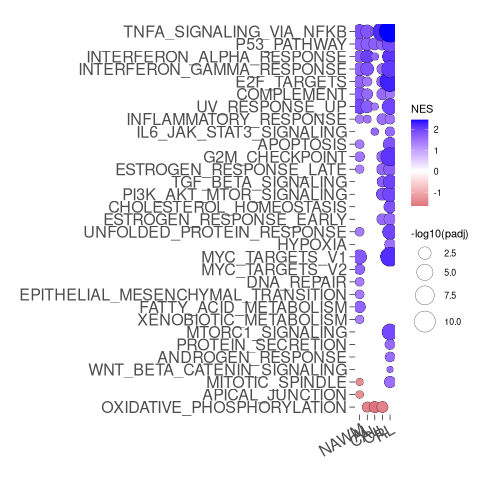

In [82]:
%%R

heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

print(heatmap_plot)

#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MOL_only_ordered.png", plot = heatmap_plot, dpi = 300, width = 7.5, height = 8)

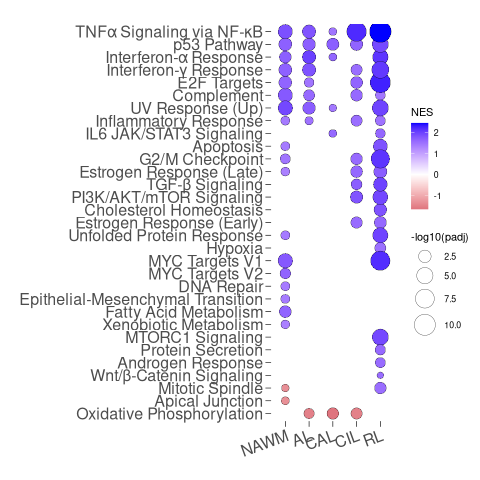

In [84]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MOL_ordered_glmm_revision_zscore.png", plot = heatmap_plot, dpi = 300, width = 7.5, height = 8)